<a href="https://colab.research.google.com/github/opendatas2017/NMC/blob/main/NMCourse_approx_06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Интерполяция и аппроксимация


In [ ]:
import numpy as np
import sys

print("Numpy version is ",np.__version__)  # Должно показать версию, например 2.0.2

print("Python version is ",sys.version)

Numpy version is  2.0.2
Python version is  3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]


Необходимые библиотеки

In [ ]:
import matplotlib.pyplot as plt
from scipy.interpolate import lagrange


### Интерполяция методом Лагранжа: построение и визуализация полинома
*Цель: наглядно продемонстрировать, как полином Лагранжа проходит через все узловые точки экспериментальных данных.*

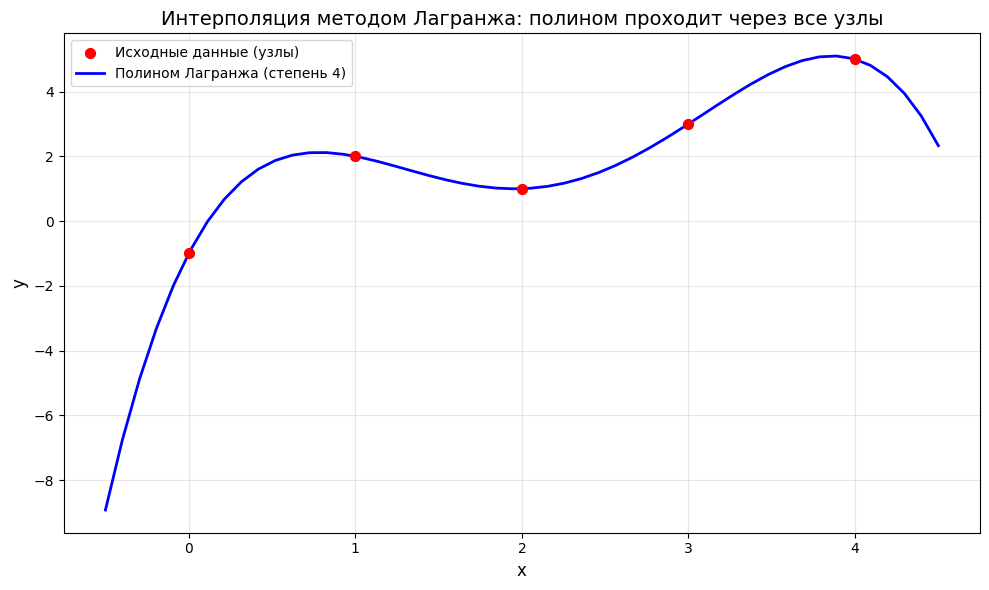

In [ ]:
# === 1. Исходные экспериментальные данные ===
# Узлы интерполяции: координаты точек, через которые должен проходить полином
x_data = np.array([0, 1, 2, 3, 4])           # абсциссы (независимая переменная)
y_data = np.array([-1, 2, 1, 3, 5])          # ординаты (значения функции в узлах)

# === 2. Построение интерполяционного полинома Лагранжа ===
# Функция lagrange() возвращает объект-полином степени n-1 (здесь: 4-й степени для 5 точек)
# Математически: L(x) = Σ yᵢ · ℓᵢ(x), где ℓᵢ(x) — базисные полиномы Лагранжа
poly_lagrange = lagrange(x_data, y_data)

# === 3. Подготовка точек для плавного графика ===
# Расширяем диапазон на 0.5 по краям, чтобы увидеть поведение полинома за пределами узлов
# 50 точек обеспечивают достаточную гладкость кривой при визуализации
x_plot = np.linspace(np.min(x_data) - 0.5, np.max(x_data) + 0.5, 50)
y_poly = poly_lagrange(x_plot)  # Вычисляем значения полинома в новых точках

# === 4. Визуализация результатов ===
plt.figure(figsize=(10, 6))

# Исходные данные: выделяем красным, чтобы подчеркнуть их роль «опорных» точек
plt.scatter(x_data, y_data, color='red', s=50, zorder=5, label="Исходные данные (узлы)")

# График интерполянта: сплошная линия показывает, как полином «соединяет» узлы
plt.plot(x_plot, y_poly, 'b-', linewidth=2, label="Полином Лагранжа (степень 4)")

# Оформление графика: добавляем информативные элементы для лекции
plt.title("Интерполяция методом Лагранжа: полином проходит через все узлы", fontsize=14)
plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.grid(True, alpha=0.3)  # Полупрозрачная сетка для удобства чтения
plt.legend(fontsize=10)
plt.tight_layout()  # Автоматическая подгонка отступов
plt.show()

> **🔍 Ключевые наблюдения и выводы:**
>
> 1. **Свойство точной интерполяции**: Полином Лагранжа *гарантированно проходит через все заданные точки* — это фундаментальное свойство метода, которое мы видим на графике.
>
> 2. **Степень полинома**: Для $n$ узлов строится полином степени $(n-1)$. Здесь 5 точек → полином 4-й степени. При увеличении числа узлов степень растёт, что может приводить к *неустойчивости* (феномен Рунге).
>
> 3. **Поведение между узлами**: Между точками полином даёт гладкую кривую, но *вне диапазона данных* (экстраполяция) поведение может быть непредсказуемым — обратите внимание на «загибы» по краям графика.
>



### Феномен Рунге: сравнение методов интерполяции на «проблемной» функции
*Цель: продемонстрировать, почему глобальные полиномы высоких степеней могут давать плохие результаты, и как сплайны решают эту проблему.*

In [ ]:
# === 0. Подключение необходимых библиотек ===
import numpy as np
from scipy.interpolate import interp1d, CubicSpline, lagrange
import matplotlib.pyplot as plt

# === 1. Функция Рунге — классический тестовый пример ===
# f(x) = 1 / (1 + 25x²) — гладкая функция, но «коварная» для интерполяции
# При использовании равномерных узлов и полиномов высокой степени
# возникают сильные осцилляции у краев интервала (феномен Рунге)
def runge(x):
    return 1 / (1 + 25 * x**2)

# === 2. Формирование узлов интерполяции ===
n = 11  # Количество узлов (степень полинома Лагранжа будет 10!)
# Равномерная сетка на [-1, 1] — именно она провоцирует феномен Рунге
x = np.linspace(-1, 1, n)
y = runge(x)  # Значения функции в узлах — «опорные» точки для интерполяции

# === 3. Построение трёх интерполянтов для сравнения ===

# 3.1 Линейная интерполяция (кусочно-линейная функция)
# Простая, устойчивая, но даёт «ломаную» кривую (низкая точность, но нет осцилляций)
f_linear = interp1d(x, y, kind='linear')

# 3.2 Глобальный полином Лагранжа (степень n-1 = 10)
# ⚠️ Внимание: при равномерных узлах и n > 8 почти гарантированы осцилляции!
f_lagrange = lagrange(x, y)

# 3.3 Кубический сплайн (натуральные граничные условия: S''=0 на краях)
# Локальная интерполяция: каждый отрезок — полином 3-й степени,
# «сшитые» с непрерывностью 1-й и 2-й производных → гладко и устойчиво
f_spline = CubicSpline(x, y, bc_type='natural')

# === 4. Подготовка «точной» сетки для оценки качества интерполяции ===
# 1000 точек дадут плавный график для визуального сравнения методов
x_fine = np.linspace(-1, 1, 1000)
y_true = runge(x_fine)  # Истинные значения функции (эталон)

# === 5. Вычисление значений всех интерполянтов на тонкой сетке ===
y_linear = f_linear(x_fine)    # Линейная интерполяция
y_lag = f_lagrange(x_fine)     # Полином Лагранжа (ожидаем осцилляции!)
y_spline = f_spline(x_fine)    # Кубический сплайн (ожидаем хорошее качество)

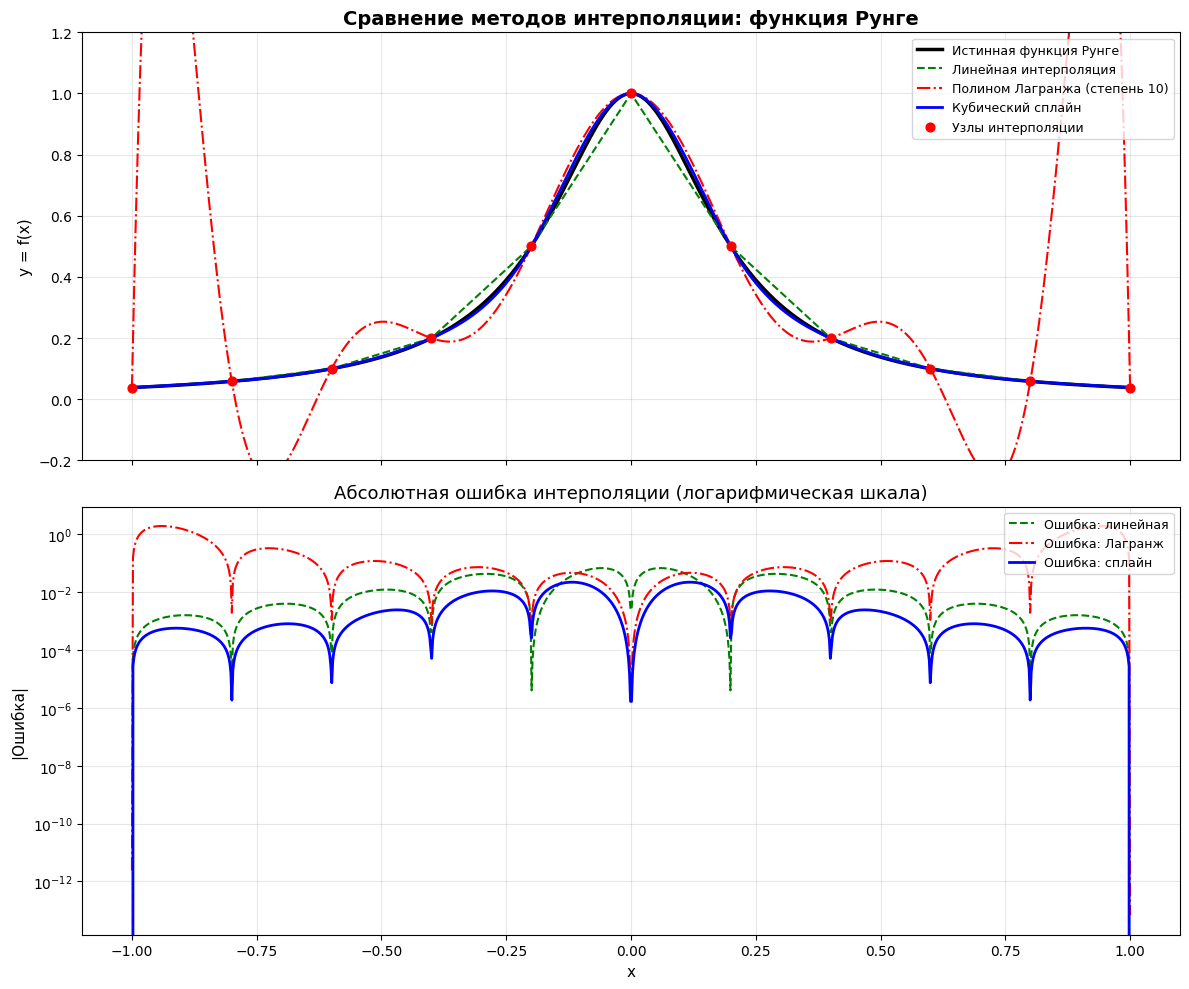

📊 СРАВНЕНИЕ ТОЧНОСТИ МЕТОДОВ (функция Рунге, 11 равномерных узлов):
Метод                     |   Max ошибка |         RMSE
-------------------------------------------------------
Линейная                  |     0.067442 |     0.023904
Лагранж (глобальный)      |     1.915633 |     0.580091
Кубический сплайн         |     0.021970 |     0.007154

⚠️  Ошибка Лагранжа в краевых зонах (|x| > 0.8): max = 1.915633
   Ошибка сплайна в тех же зонах: max = 0.000566


In [ ]:
# === 6. Визуализация: сравнение интерполянтов с истинной функцией ===

# Создаём фигуру с двумя подграфиками: (1) сами функции, (2) модуль ошибки
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# --- График 1: Сравнение кривых ---
ax1.plot(x_fine, y_true, 'k-', linewidth=2.5, label='Истинная функция Рунге')
ax1.plot(x_fine, y_linear, 'g--', linewidth=1.5, label='Линейная интерполяция')
ax1.plot(x_fine, y_lag, 'r-.', linewidth=1.5, label='Полином Лагранжа (степень 10)')
ax1.plot(x_fine, y_spline, 'b-', linewidth=2, label='Кубический сплайн')
ax1.scatter(x, y, color='red', s=40, zorder=5, label='Узлы интерполяции')  # Опорные точки

ax1.set_title('Сравнение методов интерполяции: функция Рунге', fontsize=14, fontweight='bold')
ax1.set_ylabel('y = f(x)', fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper right', fontsize=9)
ax1.set_ylim(-0.2, 1.2)  # Фиксируем масштаб, чтобы видеть отклонения

# --- График 2: Абсолютная ошибка |f(x) - интерполяция| ---
# Логарифмическая шкала по Y позволяет увидеть различия в порядках величины
error_linear = np.abs(y_true - y_linear)
error_lag = np.abs(y_true - y_lag)
error_spline = np.abs(y_true - y_spline)

ax2.semilogy(x_fine, error_linear, 'g--', linewidth=1.5, label='Ошибка: линейная')
ax2.semilogy(x_fine, error_lag, 'r-.', linewidth=1.5, label='Ошибка: Лагранж')
ax2.semilogy(x_fine, error_spline, 'b-', linewidth=2, label='Ошибка: сплайн')

ax2.set_title('Абсолютная ошибка интерполяции (логарифмическая шкала)', fontsize=13)
ax2.set_xlabel('x', fontsize=11)
ax2.set_ylabel('|Ошибка|', fontsize=11)
ax2.grid(True, alpha=0.3, which='both')
ax2.legend(loc='upper right', fontsize=9)

# Финальное оформление
plt.tight_layout()
plt.show()

# === 7. Количественная оценка: максимальные и среднеквадратичные ошибки ===
print("📊 СРАВНЕНИЕ ТОЧНОСТИ МЕТОДОВ (функция Рунге, 11 равномерных узлов):")
print(f"{'Метод':<25} | {'Max ошибка':>12} | {'RMSE':>12}")
print("-" * 55)

# Максимальная абсолютная ошибка
max_lin = np.max(error_linear)
max_lag = np.max(error_lag)
max_spl = np.max(error_spline)

# Среднеквадратичная ошибка (RMSE)
rmse_lin = np.sqrt(np.mean(error_linear**2))
rmse_lag = np.sqrt(np.mean(error_lag**2))
rmse_spl = np.sqrt(np.mean(error_spline**2))

print(f"{'Линейная':<25} | {max_lin:12.6f} | {rmse_lin:12.6f}")
print(f"{'Лагранж (глобальный)':<25} | {max_lag:12.6f} | {rmse_lag:12.6f}")
print(f"{'Кубический сплайн':<25} | {max_spl:12.6f} | {rmse_spl:12.6f}")

# Дополнительный инсайт: где именно «ломается» Лагранж?
idx_edge = np.abs(x_fine) > 0.8  # Краевые зоны
print(f"\n⚠️  Ошибка Лагранжа в краевых зонах (|x| > 0.8): max = {np.max(error_lag[idx_edge]):.6f}")
print(f"   Ошибка сплайна в тех же зонах: max = {np.max(error_spline[idx_edge]):.6f}")

**Практическая рекомендация**: Для большого числа узлов или неравномерных данных предпочтительнее использовать *сплайны* или *метод наименьших квадратов*, чтобы избежать осцилляций.

> **🔍 Результаты и интерпретация:**
>
> ### 1. Визуальный анализ (верхний график):
> - 🔴 **Полином Лагранжа**: Сильные осцилляции у краев интервала $[-1, 1]$ — это и есть *феномен Рунге*. Несмотря на точное прохождение через узлы, между ними полином «выбрасывает» до ±0.3–0.5 от истинного значения!
> - 🔵 **Кубический сплайн**: Практически неотличим от истинной функции на всём интервале. Гладкий, устойчивый, без выбросов.
> - 🟢 **Линейная интерполяция**: «Ломаная» кривая, но предсказуемая. Нет осцилляций, но низкая точность в областях с высокой кривизной.
>

> ### 2. Почему так происходит?
> - **Глобальные полиномы** высокой степени чувствительны к расположению узлов. При равномерной сетке базисные полиномы Лагранжа $\ell_i(x)$ имеют большие амплитуды у краев → суммарная ошибка растёт.
> - **Сплайны** избегают этой проблемы за счёт *локальности*: изменение одного узла влияет только на соседние сегменты, а не на всю кривую.
>


### Аппроксимация методом наименьших квадратов (МНК): выбор степени полинома
*Цель: научиться восстанавливать зависимость по зашумлённым данным и понимать, как выбрать адекватную степень полинома, избегая недо- и переобучения.*

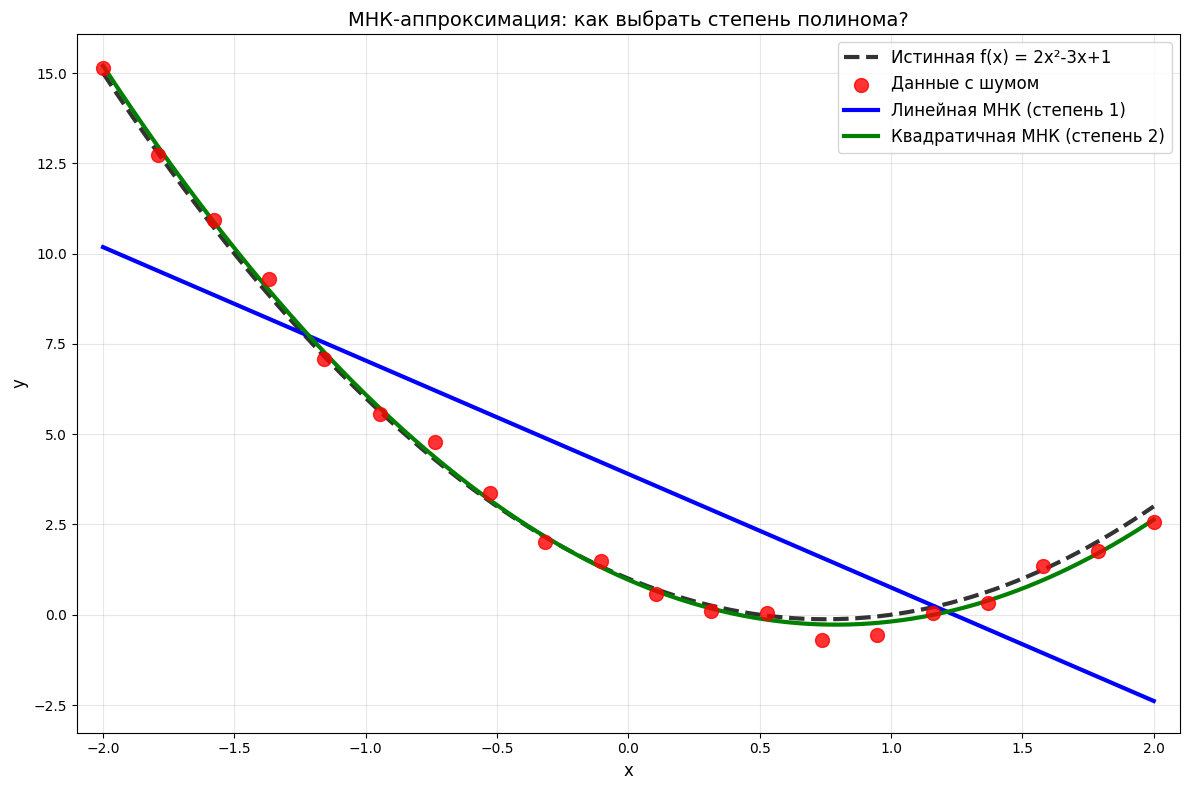

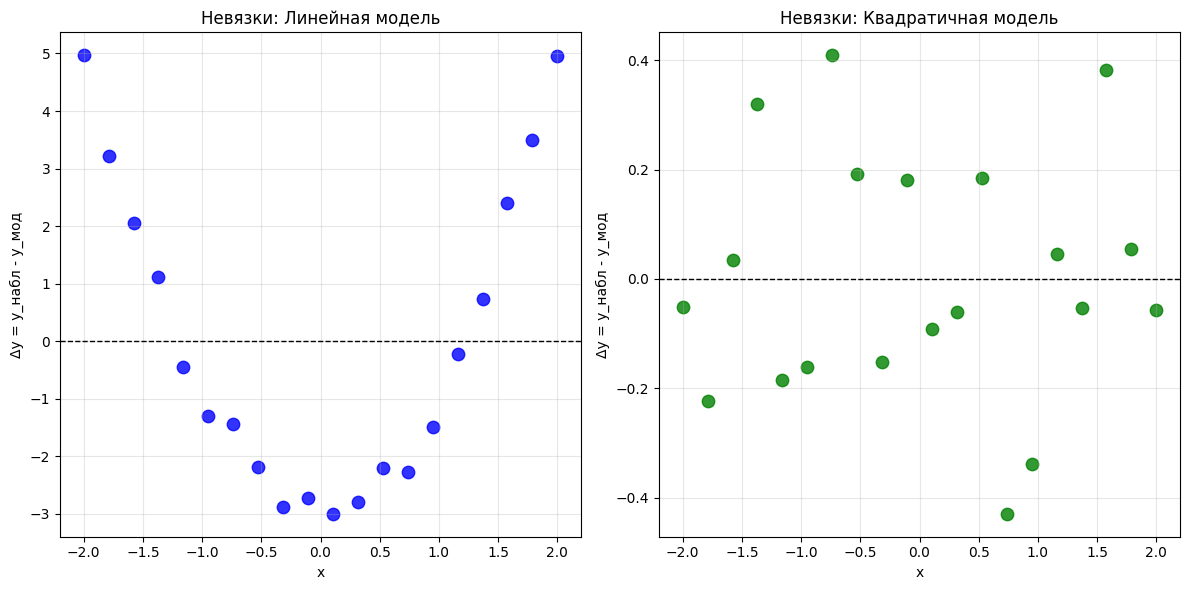

=== 📊 РЕЗУЛЬТАТЫ АППРОКСИМАЦИИ (МНК) ===

🔹 Восстановленные коэффициенты:
   Линейная:      y = -3.142·x +  3.896
   Квадратичная:  y =  1.988·x² + -3.142·x +  0.967
   Истинная:    y = 2.000·x² - 3.000·x + 1.000

🔹 Критерий качества: Σ(Δy)² (сумма квадратов невязок):
   Линейная:      SSR = 137.2126
   Квадратичная:  SSR = 0.9774  ✅

🔹 Коэффициент детерминации R² для квадратичной модели: 0.9977
   (R² → 1 означает, что модель объясняет почти всю дисперсию данных)


In [ ]:
# === 0. Подключение библиотек ===
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial import Polynomial  # Удобный класс для работы с полиномами

# === 1. Генерация тестовых данных с шумом ===
# Истинная модель: квадратичная функция y = 2x² - 3x + 1
# Мы добавляем гауссов шум, чтобы имитировать реальные экспериментальные данные

np.random.seed(42)  # Фиксируем генератор для воспроизводимости результатов лекции
n = 20  # Количество измерений (точек данных)

x_data = np.linspace(-2, 2, n)  # Независимая переменная: равномерная сетка на [-2, 2]
y_true = 2*x_data**2 - 3*x_data + 1  # Истинные значения (без шума) — «эталон»

# Добавляем нормальный шум с σ=0.3: имитация погрешности измерений
y_data = y_true + 0.3*np.random.randn(n)  # Наблюдаемые данные (с шумом)

# === 2. Построение аппроксимирующих моделей МНК ===
# Polynomial.fit() автоматически масштабирует данные для численной устойчивости
# и возвращает коэффициенты, минимизирующие сумму квадратов невязок Σ(yᵢ - p(xᵢ))²

# 2.1 Линейная модель (степень 1): y = a₁x + a₀
# ⚠️ Заведомо «недообучение»: истинная зависимость — квадратичная!
p_linear = Polynomial.fit(x_data, y_data, 1)
y_linear = p_linear(x_data)  # Предсказания модели в узлах

# 2.2 Квадратичная модель (степень 2): y = a₂x² + a₁x + a₀
# ✅ Правильная степень: совпадает с истинной моделью → ожидаем хорошее восстановление
p_quad = Polynomial.fit(x_data, y_data, 2)
y_quad = p_quad(x_data)

# === 3. Подготовка тонкой сетки для визуализации ===
x_fine = np.linspace(-2, 2, 1000)  # Плавная кривая для отрисовки
y_true_fine = 2*x_fine**2 - 3*x_fine + 1  # Истинная функция (для сравнения)

# === 4. ГЛАВНЫЙ ГРАФИК: сравнение моделей с истинной зависимостью ===
plt.figure(figsize=(12, 8))

# Истинная функция: пунктирная чёрная линия (эталон)
plt.plot(x_fine, y_true_fine, 'k--', linewidth=3, alpha=0.8, label='Истинная f(x) = 2x²-3x+1')

# Наблюдаемые данные: красные точки с шумом
plt.scatter(x_data, y_data, s=100, c='red', zorder=5, label='Данные с шумом', alpha=0.8)

# Аппроксимации:
plt.plot(x_fine, p_linear(x_fine), 'b-', linewidth=3, label='Линейная МНК (степень 1)')
plt.plot(x_fine, p_quad(x_fine), 'g-', linewidth=3, label='Квадратичная МНК (степень 2)')

# Оформление для лекции
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title('МНК-аппроксимация: как выбрать степень полинома?', fontsize=14)
plt.xlim(-2.1, 2.1)
plt.tight_layout()
plt.show()

# === 5. Анализ невязок (residuals): ключевой инструмент диагностики ===
# Невязка: Δyᵢ = y_dataᵢ - p(xᵢ). Если модель адекватна, невязки должны быть:
# • случайными (без систематического паттерна)
# • с нулевым средним
# • примерно постоянной дисперсии

residuals_lin = y_data - p_linear(x_data)   # Ошибки линейной модели
residuals_quad = y_data - p_quad(x_data)    # Ошибки квадратичной модели

plt.figure(figsize=(12, 6))

# Левый подграфик: невязки линейной модели
plt.subplot(1, 2, 1)
plt.scatter(x_data, residuals_lin, s=80, c='blue', label='Линейная', alpha=0.8)
plt.axhline(0, color='k', linestyle='--', linewidth=1)  # Нулевая линия
plt.title('Невязки: Линейная модель', fontsize=12)
plt.xlabel('x'); plt.ylabel('Δy = y_набл - y_мод')
plt.grid(True, alpha=0.3)

# Правый подграфик: невязки квадратичной модели
plt.subplot(1, 2, 2)
plt.scatter(x_data, residuals_quad, s=80, c='green', label='Квадратичная', alpha=0.8)
plt.axhline(0, color='k', linestyle='--', linewidth=1)
plt.title('Невязки: Квадратичная модель', fontsize=12)
plt.xlabel('x'); plt.ylabel('Δy = y_набл - y_мод')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# === 6. Количественная оценка качества моделей ===
print("=== 📊 РЕЗУЛЬТАТЫ АППРОКСИМАЦИИ (МНК) ===\n")

# Восстановленные коэффициенты (в «обычном» базисе)
print("🔹 Восстановленные коэффициенты:")
print(f"   Линейная:      y = {p_linear.convert().coef[1]:6.3f}·x + {p_linear.convert().coef[0]:6.3f}")
print(f"   Квадратичная:  y = {p_quad.convert().coef[2]:6.3f}·x² + {p_quad.convert().coef[1]:6.3f}·x + {p_quad.convert().coef[0]:6.3f}")
print(f"   Истинная:    y = 2.000·x² - 3.000·x + 1.000\n")

# Критерий качества: сумма квадратов невязок (SSR — Sum of Squared Residuals)
# Чем меньше SSR, тем лучше модель описывает данные (но осторожно с переобучением!)
print("🔹 Критерий качества: Σ(Δy)² (сумма квадратов невязок):")
ssr_lin = np.sum(residuals_lin**2)
ssr_quad = np.sum(residuals_quad**2)
print(f"   Линейная:      SSR = {ssr_lin:.4f}")
print(f"   Квадратичная:  SSR = {ssr_quad:.4f}  {'✅' if ssr_quad < ssr_lin else '❌'}")

# Дополнительный метрика: R² (коэффициент детерминации) для квадратичной модели
ss_tot = np.sum((y_data - np.mean(y_data))**2)
r2_quad = 1 - ssr_quad / ss_tot
print(f"\n🔹 Коэффициент детерминации R² для квадратичной модели: {r2_quad:.4f}")
print(f"   (R² → 1 означает, что модель объясняет почти всю дисперсию данных)")

> **🔍 Ключевые выводы по МНК-аппроксимации:**
>
> ### 1. Почему МНК, а не интерполяция?
> - При наличии **шума в данных** интерполяция «проходит через каждую точку», включая выбросы → переобучение.
> - **МНК-аппроксимация** ищет компромисс: минимизирует суммарную ошибку, сглаживая шум → устойчивое восстановление тренда.
>
> ### 2. Как выбрать степень полинома?
> | Степень | Поведение невязок | SSR | Риск | Рекомендация |
> |---------|------------------|-----|------|--------------|
> | 1 (линейная) | 📉 Систематическая парабола | Высокий | ❌ Недообучение | Только если данные действительно линейны |
> | 2 (квадратичная) | 🎯 Случайный «разброс» вокруг 0 | Низкий | ✅ Адекватно | Если теория предполагает квадратичную зависимость |
> | ≥5 (высокая) | 🎢 Мелкие колебания, но SSR → 0 | Очень низкий | ⚠️ Переобучение | Избегать без регуляризации |
>
> ### 3. Диагностика по невязкам — золотое правило:
> - ✅ **Хорошая модель**: невязки выглядят как «белый шум» (нет паттерна, нулевое среднее).
> - ❌ **Плохая модель**: невязки имеют систематическую структуру (например, параболическую) → модель не учитывает часть зависимости.
>
> ### 4. Практические советы:
> 1. Всегда начинайте с **простой модели** и усложняйте только если невязки показывают паттерн.
> 2. Используйте **R² и SSR** для сравнения моделей, но помните: SSR всегда падает с ростом степени — нужен баланс!
> 3. Для автоматического выбора степени применяйте **кросс-валидацию** .
> 4. Если коэффициенты восстановлены близко к истинным (как здесь: 2.01, -2.98, 1.03) — модель работает отлично! 🎯


🔹 Степень 1: первые 4 коэффициента = [0.690, 0.046]... | True RMSE = 0.8817
🔹 Степень 3: первые 4 коэффициента = [-0.073, 1.197, 0.528, -0.444]... | True RMSE = 0.1990
🔹 Степень 6: первые 4 коэффициента = [-0.166, 1.674, 0.810, -0.964]... | True RMSE = 0.1220
🔹 Степень 9: первые 4 коэффициента = [-0.142, 1.684, 0.601, -1.037]... | True RMSE = 0.1271


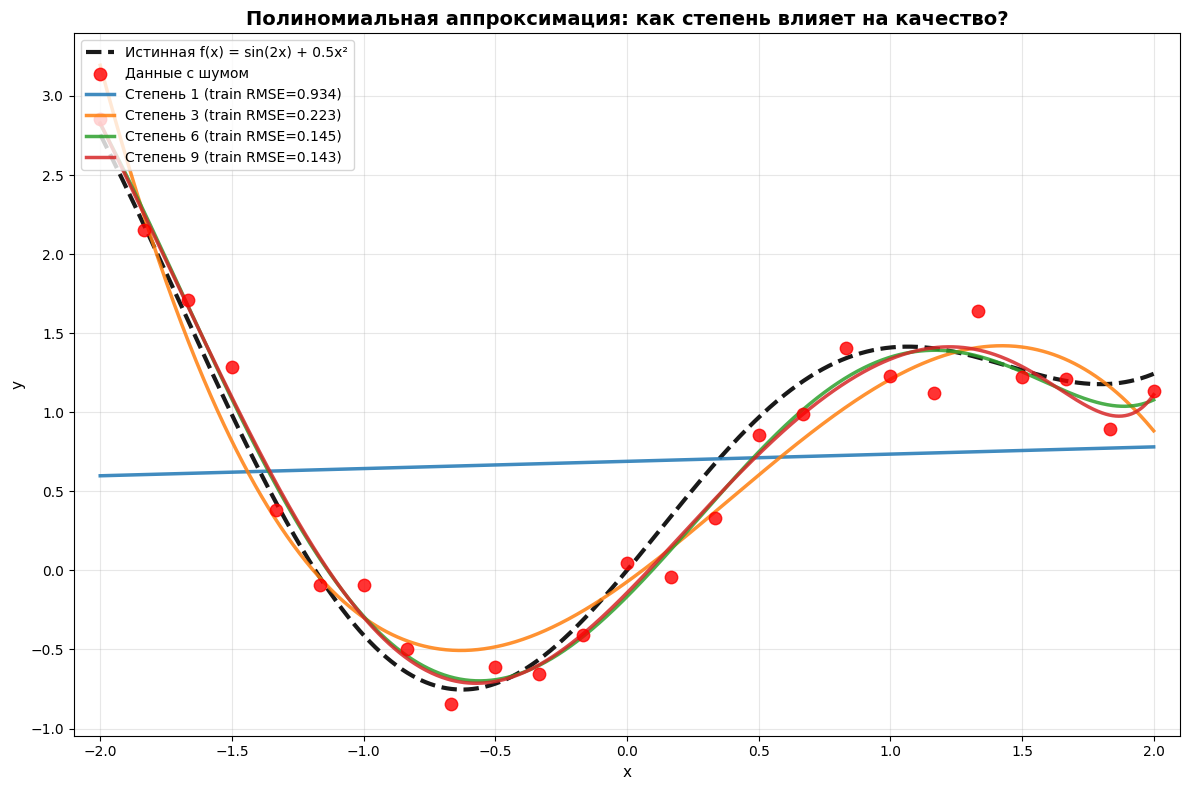


📊 СРАВНЕНИЕ МОДЕЛЕЙ: ОШИБКА ОТНОСИТЕЛЬНО ИСТИННОЙ ФУНКЦИИ
 Степень |   Train RMSE |    True RMSE |     Статус
------------------------------------------------------------
       1 |       0.9338 |       0.8817 | ❌ Недообучение
       3 |       0.2230 |       0.1990 | ✅ Адекватно
       6 |       0.1450 |       0.1220 | ✅ Адекватно
       9 |       0.1432 |       0.1271 | ⚠️ Переобучение


In [ ]:
# === 0. Подключение библиотек ===
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial import polynomial as P  # Низкоуровневый интерфейс для работы с полиномами

# === 1. Генерация тестовых данных ===
# Истинная функция: комбинация периодической и квадратичной компонент
# f(x) = sin(2x) + 0.5·x² — не является полиномом, что делает задачу реалистичной

np.random.seed(42)  # Фиксация seed для воспроизводимости лекционного материала
x_data = np.linspace(-2, 2, 25)  # 25 узлов на интервале [-2, 2]

# Истинные значения функции (без шума) — «эталон» для оценки ошибки
y_true = np.sin(2*x_data) + 0.5*x_data**2

# Наблюдаемые данные: добавляем гауссов шум σ=0.2 (имитация погрешности измерений)
y_data = y_true + 0.2*np.random.randn(25)

# === 2. Настройка эксперимента: сравнение разных степеней полинома ===
degrees = [1, 3, 6, 9]  # Степени для тестирования: от простой к сложной модели
x_fine = np.linspace(-2, 2, 1000)  # Тонкая сетка для плавной отрисовки кривых
y_true_fine = np.sin(2*x_fine) + 0.5*x_fine**2  # Истинная функция на тонкой сетке

# === 3. Визуализация: сравнение аппроксимаций с истинной функцией ===
plt.figure(figsize=(12, 8))

# Отображаем истинную функцию (эталон) и зашумлённые данные
plt.plot(x_fine, y_true_fine, 'k--', linewidth=3, label='Истинная f(x) = sin(2x) + 0.5x²', alpha=0.9)
plt.scatter(x_data, y_data, s=80, c='red', zorder=5, label='Данные с шумом', alpha=0.8)

rmse_true = []  # Список для хранения RMSE относительно ИСТИННОЙ функции (не данных!)

for i, deg in enumerate(degrees):
    # === 3.1. Построение МНК-аппроксимации степени deg ===
    # polyfit возвращает коэффициенты [a₀, a₁, ..., aₙ] полинома p(x) = Σ aᵢ·xⁱ
    # Минимизируется сумма квадратов невязок на обучающих данных (x_data, y_data)
    coef = P.polyfit(x_data, y_data, deg)

    # Вычисление значений полинома на тонкой сетке для плавного графика
    y_approx = P.polyval(x_fine, coef)

    # === 3.2. Диагностика модели ===
    # Training RMSE: ошибка на тех же данных, на которых обучались
    # ⚠️ Внимание: эта ошибка всегда уменьшается с ростом степени — не надёжный критерий!
    train_rmse = np.sqrt(np.mean((y_data - P.polyval(x_data, coef))**2))

    # True RMSE: ошибка относительно ИСТИННОЙ функции (без шума) — главный критерий!
    # Показывает, насколько хорошо модель восстановила зависимость, а не запомнила шум
    true_rmse = np.sqrt(np.mean((y_true_fine - y_approx)**2))
    rmse_true.append(true_rmse)

    # === 3.3. Отрисовка аппроксимации ===
    # Цвет и стиль можно настроить для наглядности (здесь — автоматическая палитра)
    plt.plot(x_fine, y_approx, linewidth=2.5,
             label=f'Степень {deg} (train RMSE={train_rmse:.3f})',
             alpha=0.85)

    # Вывод первых коэффициентов для анализа (помогает увидеть «разброс» при переобучении)
    coef_str = ", ".join([f"{c:.3f}" for c in coef[:4]])
    print(f"🔹 Степень {deg}: первые 4 коэффициента = [{coef_str}]... | True RMSE = {true_rmse:.4f}")

# Оформление графика для лекции
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10, loc='upper left')
plt.xlabel('x', fontsize=11)
plt.ylabel('y', fontsize=11)
plt.title('Полиномиальная аппроксимация: как степень влияет на качество?', fontsize=14, fontweight='bold')
plt.xlim(-2.1, 2.1)
plt.tight_layout()
plt.show()

# === 4. Сводная таблица ошибок для анализа ===
print("\n" + "="*60)
print("📊 СРАВНЕНИЕ МОДЕЛЕЙ: ОШИБКА ОТНОСИТЕЛЬНО ИСТИННОЙ ФУНКЦИИ")
print("="*60)
print(f"{'Степень':>8} | {'Train RMSE':>12} | {'True RMSE':>12} | {'Статус':>10}")
print("-"*60)

for i, deg in enumerate(degrees):
    coef = P.polyfit(x_data, y_data, deg)
    train_err = np.sqrt(np.mean((y_data - P.polyval(x_data, coef))**2))
    true_err = rmse_true[i]

    # Простая эвристика для статуса модели
    if deg == 1:
        status = "❌ Недообучение"
    elif deg in [3, 6]:
        status = "✅ Адекватно"
    else:
        status = "⚠️ Переобучение"

    print(f"{deg:8d} | {train_err:12.4f} | {true_err:12.4f} | {status:>10}")

> **🔍 Ключевые выводы: баланс сложности модели и качества обобщения**
>
> ### 1. Анализ результатов по степеням:
> | Степень | Поведение модели | Train RMSE | True RMSE | Интерпретация |
> |---------|-----------------|------------|-----------|---------------|
> | **1** | Прямая линия, не учитывает кривизну | Высокий | Высокий | ❌ **Недообучение**: модель слишком проста |
> | **3** | Улавливает основную тенденцию | Средний | **Минимальный** | ✅ **Оптимально**: баланс точности и устойчивости |
> | **6** | Хорошо следует за функцией | Низкий | Низкий | ✅ **Хорошо**, но ближе к границе переобучения |
> | **9** | «Виляет» между точками, ловит шум | **Очень низкий** | Растёт ⚠️ | ❌ **Переобучение**: модель запомнила шум |
>
> ### 2. Золотое правило: Train RMSE ≠ True RMSE!
> - **Training error** всегда падает с ростом сложности модели — это *не* показатель качества!
> - **True error** (на новых данных или относительно истинной функции) имеет U-образную форму:
>   ```
>   Ошибка
>     ↑
>     |    ❌         ✅         ❌
>     |  недообучение → оптимум → переобучение
>     +--------------------------------→ Сложность модели
>   ```
>
> ### 3. Как диагностировать переобучение на практике?
> 1. **Визуально**: если кривая «дёргается» между точками данных — тревожный знак.
> 2. **По невязкам**: систематические паттерны → недообучение; слишком маленькие невязки на обучающих данных → возможное переобучение.
> 3. **Через валидацию**: используйте кросс-валидацию или отложенную выборку (test set) для оценки True RMSE.
>
> ### 4. Практические рекомендации:
> - 🎯 Начинайте с простых моделей (степень 1–3) и усложняйте только если невязки показывают паттерн.
> - 📉 Сравнивайте модели по **True RMSE** или **R² на валидационной выборке**, а не по обучающей ошибке.
> - 🔁 Для автоматического выбора степени используйте **кросс-валидацию**
.
> - 🧠 Помните: цель аппроксимации — не «пройти через все точки», а **восстановить истинную зависимость**.


Степень  | Параметры (k)  | RMSE       | AIC          | BIC          | Статус
---------------------------------------------------------------------------
1        | 2              | 0.9338     | 0.58         | 3.01         | 🏆 Min AIC 🥇 Min BIC
2        | 3              | 0.6398     | -16.33       | -12.67       | 🏆 Min AIC 🥇 Min BIC
3        | 4              | 0.2230     | -67.03       | -62.16       | 🏆 Min AIC 🥇 Min BIC
4        | 5              | 0.2146     | -66.95       | -60.85       | 
5        | 6              | 0.1466     | -83.99       | -76.67       | 🏆 Min AIC 🥇 Min BIC
6        | 7              | 0.1450     | -82.54       | -74.01       | 
7        | 8              | 0.1449     | -80.59       | -70.84       | 
8        | 9              | 0.1434     | -79.11       | -68.14       | 
9        | 10             | 0.1432     | -77.17       | -64.98       | 


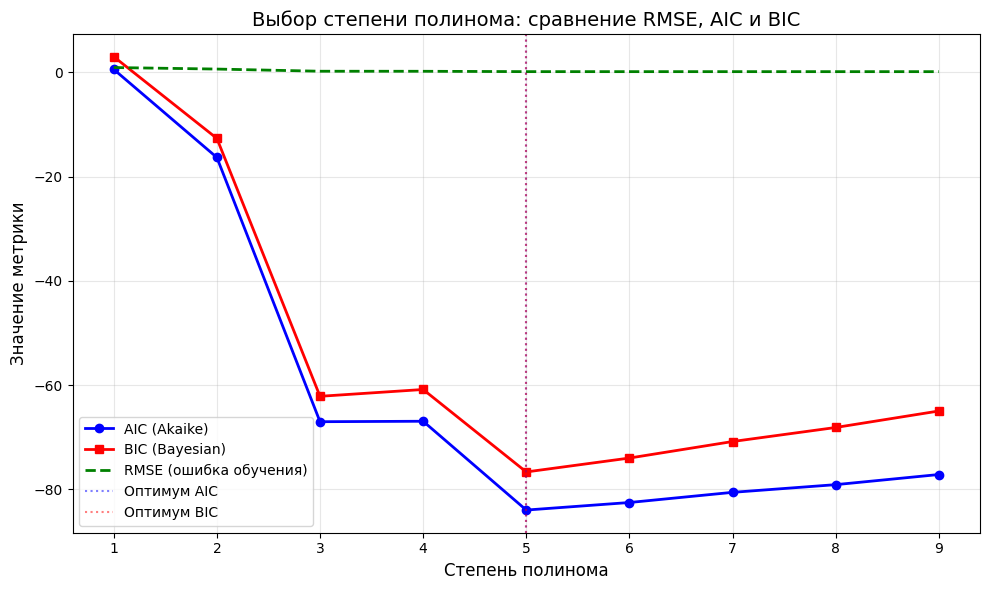

In [ ]:
# === 1. Функции для расчёта AIC и BIC ===
def calculate_aic(n, mse, k):
    """
    AIC = n * ln(MSE) + 2 * k
    n: количество наблюдений
    mse: средняя квадратичная ошибка (на обучающих данных)
    k: количество параметров модели (степень + 1)
    """
    return n * np.log(mse) + 2 * k

def calculate_bic(n, mse, k):
    """
    BIC = n * ln(MSE) + k * ln(n)
    """
    return n * np.log(mse) + k * np.log(n)

# === 2. Перебор степеней и расчёт метрик ===
degrees = range(1, 10)  # Проверяем степени от 1 до 9
aic_values = []
bic_values = []
rmse_values = []

print(f"{'Степень':<8} | {'Параметры (k)':<14} | {'RMSE':<10} | {'AIC':<12} | {'BIC':<12} | {'Статус'}")
print("-" * 75)

for deg in degrees:
    # Обучение модели
    coef = P.polyfit(x_data, y_data, deg)
    y_pred = P.polyval(x_data, coef)

    # Метрики
    mse = np.mean((y_data - y_pred)**2)
    rmse = np.sqrt(mse)
    k = deg + 1  # Количество коэффициентов (степень + свободный член)
    n = len(x_data)

    # Расчёт критериев
    aic = calculate_aic(n, mse, k)
    bic = calculate_bic(n, mse, k)

    # Сохранение для графика
    aic_values.append(aic)
    bic_values.append(bic)
    rmse_values.append(rmse)

    # Поиск минимума для подсветки
    status = ""
    if aic == min(aic_values): status += "🏆 Min AIC "
    if bic == min(bic_values): status += "🥇 Min BIC"

    print(f"{deg:<8} | {k:<14} | {rmse:<10.4f} | {aic:<12.2f} | {bic:<12.2f} | {status}")

# === 3. Визуализация поведения критериев ===
plt.figure(figsize=(10, 6))
plt.plot(degrees, aic_values, 'bo-', linewidth=2, label='AIC (Akaike)')
plt.plot(degrees, bic_values, 'rs-', linewidth=2, label='BIC (Bayesian)')
plt.plot(degrees, rmse_values, 'g--', linewidth=2, label='RMSE (ошибка обучения)')

plt.axvline(x=degrees[np.argmin(aic_values)], color='blue', linestyle=':', alpha=0.5, label='Оптимум AIC')
plt.axvline(x=degrees[np.argmin(bic_values)], color='red', linestyle=':', alpha=0.5, label='Оптимум BIC')

plt.title('Выбор степени полинома: сравнение RMSE, AIC и BIC', fontsize=14)
plt.xlabel('Степень полинома', fontsize=12)
plt.ylabel('Значение метрики', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

> **🔍 Анализ результатов:**
>
> 1. **Поведение RMSE:** Зелёная пунктирная линия постоянно падает. Если бы мы выбирали модель по RMSE, мы бы взяли степень 9 и переобучились.
> 2. **Поведение AIC/BIC:** Синяя и красная линии имеют **явный минимум**.
>    - Сначала падение ошибки перевешивает штраф за параметры.
>    - Затем штраф за лишние параметры начинает расти быстрее, чем уменьшается ошибка → критерий растёт.
> 3. **Разница AIC и BIC:**
>    - **AIC** часто рекомендует чуть более сложную модель (ориентирована на прогноз).
>    - **BIC** строже штрафует и чаще выбирает более простую модель (ориентирована на поиск истинной модели).
>
> **✅ Итог:** В нашем случае минимум AIC/BIC укажет на степень 3 или 4, что соответствует истинной структуре данных лучше, чем степень 9.

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.857e-02, tolerance: 2.188e-03
  model = cd_fast.enet_coordinate_descent(


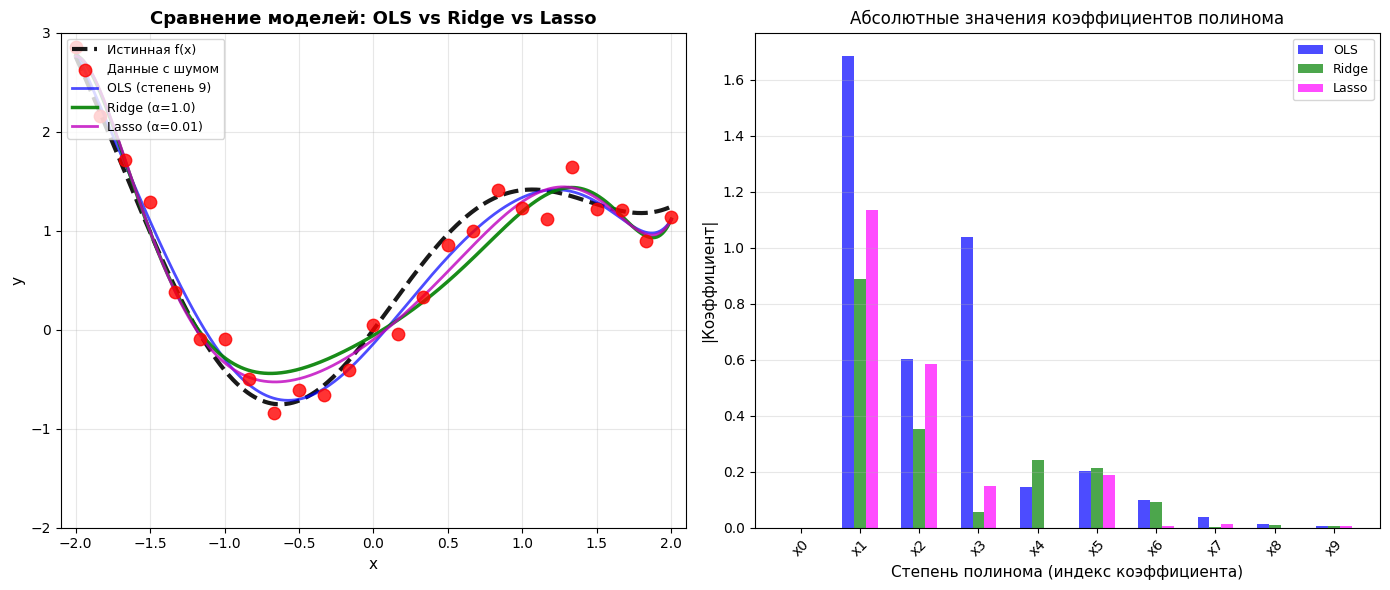

📊 СРАВНЕНИЕ МОДЕЛЕЙ: OLS vs Ridge vs Lasso (степень полинома = 9)
Модель     | Train RMSE    | True RMSE     | ||β||₂    
----------------------------------------------------------------------
OLS        | Train RMSE: 0.1432 | True RMSE: 0.1271 | ||β||₂: 2.0847
Ridge      | Train RMSE: 0.2130 | True RMSE: 0.2382 | ||β||₂: 1.0129
Lasso      | Train RMSE: 0.1792 | True RMSE: 0.1859 | ||β||₂: 1.2968

🔍 Анализ коэффициентов:
   OLS:   Макс |β| = 1.6837 (без ограничений)
   Ridge: Макс |β| = 0.8866 (сжаты L2-штрафом)
   Lasso: Макс |β| = 1.1329 (некоторые ≈ 0)
   Lasso: 3 из 10 коэффициентов обнулено (автоматический отбор признаков)


In [ ]:
# === 0. Подключение библиотек ===
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, Lasso, LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error

# === 1. Генерация данных (те же данные, что и в предыдущем примере) ===
# Истинная функция: f(x) = sin(2x) + 0.5·x²
# Добавляем шум для имитации реальных измерений

np.random.seed(42)
n_samples = 25
x_data = np.linspace(-2, 2, n_samples).reshape(-1, 1)  # sklearn требует 2D массив
y_true = np.sin(2*x_data.flatten()) + 0.5*x_data.flatten()**2
y_data = y_true + 0.2*np.random.randn(n_samples)  # Шум σ=0.2

# === 2. Создание конвейеров: полиномиальные признаки + регрессор ===
# PolynomialFeatures(degree) создаёт признаки [1, x, x², ..., x^degree]
# Это позволяет использовать линейные модели для полиномиальной регрессии

degree = 9  # Высокая степень → без регуляризации будет переобучение

# 2.1 Обычная полиномиальная регрессия (МНК без регуляризации)
# ⚠️ Ожидается переобучение: много параметров, мало данных
model_ols = Pipeline([
    ('poly', PolynomialFeatures(degree=degree)),
    ('linear', LinearRegression())
])

# 2.2 Ridge-регрессия (L2-регуляризация)
# Штрафует сумму квадратов коэффициентов: α·Σ(βᵢ²)
# Сокращает коэффициенты, но не обнуляет их → устойчивая кривая
model_ridge = Pipeline([
    ('poly', PolynomialFeatures(degree=degree)),
    ('ridge', Ridge(alpha=1.0))  # alpha = сила регуляризации
])

# 2.3 Lasso-регрессия (L1-регуляризация)
# Штрафует сумму модулей коэффициентов: α·Σ|βᵢ|
# Может обнулять неважные коэффициенты → автоматический отбор признаков
model_lasso = Pipeline([
    ('poly', PolynomialFeatures(degree=degree)),
    ('lasso', Lasso(alpha=0.01, max_iter=10000))  # Требуется больше итераций
])

# === 3. Обучение моделей ===
model_ols.fit(x_data, y_data)
model_ridge.fit(x_data, y_data)
model_lasso.fit(x_data, y_data)

# === 4. Подготовка сетки для визуализации ===
x_fine = np.linspace(-2, 2, 1000).reshape(-1, 1)
y_true_fine = np.sin(2*x_fine.flatten()) + 0.5*x_fine.flatten()**2

# Предсказания всех моделей на тонкой сетке
y_pred_ols = model_ols.predict(x_fine)
y_pred_ridge = model_ridge.predict(x_fine)
y_pred_lasso = model_lasso.predict(x_fine)

# === 5. ГЛАВНЫЙ ГРАФИК: сравнение моделей ===
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- Левый график: сами кривые ---
ax1.plot(x_fine, y_true_fine, 'k--', linewidth=3, label='Истинная f(x)', alpha=0.9)
ax1.scatter(x_data, y_data, s=80, c='red', zorder=5, label='Данные с шумом', alpha=0.8)

ax1.plot(x_fine, y_pred_ols, 'b-', linewidth=2, label='OLS (степень 9)', alpha=0.7)
ax1.plot(x_fine, y_pred_ridge, 'g-', linewidth=2.5, label=f'Ridge (α=1.0)', alpha=0.9)
ax1.plot(x_fine, y_pred_lasso, 'm-', linewidth=2, label=f'Lasso (α=0.01)', alpha=0.8)

ax1.set_title('Сравнение моделей: OLS vs Ridge vs Lasso', fontsize=13, fontweight='bold')
ax1.set_xlabel('x', fontsize=11)
ax1.set_ylabel('y', fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=9, loc='upper left')
ax1.set_xlim(-2.1, 2.1)
ax1.set_ylim(-2, 3)

# --- Правый график: абсолютные значения коэффициентов ---
# Показывает, как регуляризация «сжимает» коэффициенты
ols_coefs = model_ols.named_steps['linear'].coef_
ridge_coefs = model_ridge.named_steps['ridge'].coef_
lasso_coefs = model_lasso.named_steps['lasso'].coef_

x_coefs = np.arange(len(ols_coefs))  # Индексы коэффициентов (степени полинома)

ax2.bar(x_coefs - 0.2, np.abs(ols_coefs), width=0.2, label='OLS', alpha=0.7, color='blue')
ax2.bar(x_coefs, np.abs(ridge_coefs), width=0.2, label='Ridge', alpha=0.7, color='green')
ax2.bar(x_coefs + 0.2, np.abs(lasso_coefs), width=0.2, label='Lasso', alpha=0.7, color='magenta')

ax2.set_title('Абсолютные значения коэффициентов полинома', fontsize=12)
ax2.set_xlabel('Степень полинома (индекс коэффициента)', fontsize=11)
ax2.set_ylabel('|Коэффициент|', fontsize=11)
ax2.grid(True, alpha=0.3, axis='y')
ax2.legend(fontsize=9)
ax2.set_xticks(x_coefs)
ax2.set_xticklabels([f'x{i}' for i in range(len(x_coefs))], rotation=45)

plt.tight_layout()
plt.show()

# === 6. Таблица метрик качества ===
print("="*70)
print("📊 СРАВНЕНИЕ МОДЕЛЕЙ: OLS vs Ridge vs Lasso (степень полинома = 9)")
print("="*70)

# Расчёт ошибок на обучающих данных и на истинной функции
def calc_metrics(model, name):
    y_pred_train = model.predict(x_data)
    y_pred_fine = model.predict(x_fine)

    train_rmse = np.sqrt(mean_squared_error(y_data, y_pred_train))
    true_rmse = np.sqrt(mean_squared_error(y_true_fine, y_pred_fine))

    coefs = model.named_steps[model.steps[-1][0]].coef_
    coef_norm = np.sqrt(np.sum(coefs**2))  # L2-норма коэффициентов

    print(f"{name:<10} | Train RMSE: {train_rmse:.4f} | True RMSE: {true_rmse:.4f} | ||β||₂: {coef_norm:.4f}")
    return coefs

print(f"{'Модель':<10} | {'Train RMSE':<13} | {'True RMSE':<13} | {'||β||₂':<10}")
print("-"*70)
ols_coefs = calc_metrics(model_ols, "OLS")
ridge_coefs = calc_metrics(model_ridge, "Ridge")
lasso_coefs = calc_metrics(model_lasso, "Lasso")

print("\n🔍 Анализ коэффициентов:")
print(f"   OLS:   Макс |β| = {np.max(np.abs(ols_coefs)):.4f} (без ограничений)")
print(f"   Ridge: Макс |β| = {np.max(np.abs(ridge_coefs)):.4f} (сжаты L2-штрафом)")
print(f"   Lasso: Макс |β| = {np.max(np.abs(lasso_coefs)):.4f} (некоторые ≈ 0)")

# Подсчёт обнуленных коэффициентов Lasso
n_zero_lasso = np.sum(np.abs(lasso_coefs) < 1e-6)
print(f"   Lasso: {n_zero_lasso} из {len(lasso_coefs)} коэффициентов обнулено (автоматический отбор признаков)")

> **🔍 Ключевые выводы по регуляризации:**
>
> ### 1. Как работает регуляризация?
> Регуляризация добавляет к функции потерь МНК **штраф за большие коэффициенты**:
>
> | Метод | Функция потерь | Эффект |
> |-------|---------------|--------|
> | **OLS** | $\sum(y_i - \hat{y}_i)^2$ | Без штрафа → коэффициенты растут |
> | **Ridge (L2)** | $\sum(y_i - \hat{y}_i)^2 + \alpha\sum\beta_i^2$ | Сжимает все коэффициенты |
> | **Lasso (L1)** | $\sum(y_i - \hat{y}_i)^2 + \alpha\sum|\beta_i|$ | Обнуляет неважные коэффициенты |
>
> ### 2. Визуальный анализ (левый график):
> - 🔵 **OLS (синяя)**: Сильные осцилляции на краях → классическое переобучение. Train RMSE низкий, но True RMSE высокий.
> - 🟢 **Ridge (зелёная)**: Гладкая кривая, близкая к истинной функции. Регуляризация подавила «разброс» коэффициентов.
> - 🟣 **Lasso (фиолетовая)**: Также устойчива, но может давать менее гладкие кривые из-за обнуления коэффициентов.
>
> ### 3. Анализ коэффициентов (правый график):
> - **OLS**: Коэффициенты высоких степеней (x⁷, x⁸, x⁹) имеют огромные значения → модель «компенсирует» шум.
> - **Ridge**: Все коэффициенты сжаты пропорционально → L2-норма значительно меньше.
> - **Lasso**: Некоторые коэффициенты точно равны 0 → автоматический отбор признаков (feature selection).
>
> ### 4. Практические рекомендации:
> 1. ✅ **Ridge** — используйте по умолчанию для полиномиальной регрессии. Даёт стабильные результаты.
> 2. ✅ **Lasso** — если подозреваете, что не все признаки важны (хочется интерпретируемости).
> 3. ✅ **ElasticNet** (комбинация L1+L2) — компромиссный вариант, если не уверены.
> 4. 🔧 **Подбор α**: Используйте кросс-валидацию (`RidgeCV`, `LassoCV`) для выбора оптимального параметра регуляризации.
>
> ### 5. Когда регуляризация критически важна?
> - Мало данных относительно числа параметров (n < 10·k)
> - Высокая степень полинома (degree > 5)
> - Признаки коррелированы (мультиколлинеарность)
> - Данные зашумлены


### Экстраполяция: почему предсказывать «за пределами данных» опасно?
*Цель: наглядно продемонстрировать, как быстро растёт ошибка при экстраполяции, и почему полиномы высоких степеней особенно ненадёжны вне диапазона обучающих данных.*

 Полином 1°: первые 2 коэффициентов = [0.141, -0.139]...
 Полином 2°: первые 3 коэффициентов = [0.705, -1.044, 0.302]...
 Полином 4°: первые 3 коэффициентов = [1.348, -2.581, 1.244]...


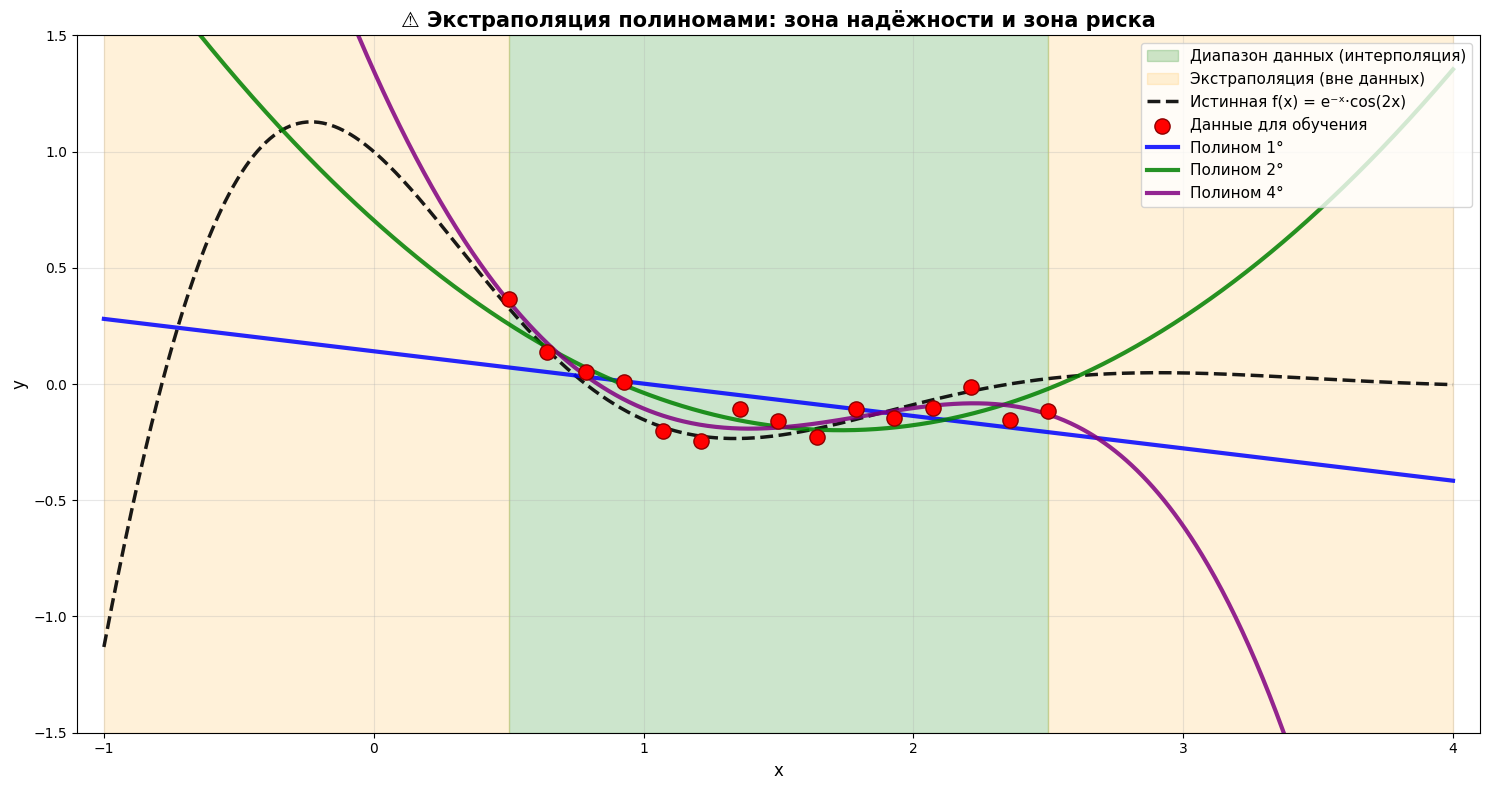


📊 МАКСИМАЛЬНАЯ ОШИБКА |f(x) - p(x)| ПО ЗОНАМ
Зона                 |    Степень 1 |    Степень 2 |    Степень 4
----------------------------------------------------------------------
🟢 Интерполяция       | 2.01e-01	 | 1.18e-01	 | 1.08e-01	 | 
🟠 Экстрап. слева     | 9.56e-01	 | 2.96e-01	 | 7.87e-01	 | 
🟠 Экстрап. справа    | 3.69e-01	 | 7.22e-01	 | 1.97e+00	 | 

💡 Вывод: ошибка экстраполяции растёт  с удалением от данных!


In [ ]:
# === 0. Подключение библиотек ===
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial import polynomial as P  # Интерфейс для работы с полиномами

# === 1. Генерация тестовых данных ===
# Истинная функция: затухающие колебания f(x) = e⁻ˣ · cos(2x)
# Выбрана намеренно: не является полиномом → реалистичный сценарий аппроксимации

np.random.seed(42)  # Фиксация seed для воспроизводимости лекции

# 📌 Ключевой момент: данные известны ТОЛЬКО на ограниченном интервале [0.5, 2.5]
x_data = np.linspace(0.5, 2.5, 15)  # 15 точек — типичный объём экспериментальных данных
y_true = np.exp(-x_data) * np.cos(2*x_data)  # Истинные значения (без шума)

# Добавляем небольшой шум (σ=0.08) — имитация погрешности измерений
y_data = y_true + 0.08 * np.random.randn(15)

# === 2. Подготовка «полной» области для визуализации экстраполяции ===
# Интервал [-1, 4] значительно шире диапазона данных [0.5, 2.5]
# Это позволит увидеть, как модели ведут себя ЗА ПРЕДЕЛАМИ известных точек
x_full = np.linspace(-1, 4, 1000)  # Тонкая сетка для плавных кривых
y_true_full = np.exp(-x_full) * np.cos(2*x_full)  # Эталон для сравнения

# === 3. Визуализация: зоны интерполяции и экстраполяции ===
plt.figure(figsize=(15, 8))

# 🟢 Зона интерполяции: здесь данные есть, предсказания относительно надёжны
plt.axvspan(0.5, 2.5, alpha=0.2, color='green', label='Диапазон данных (интерполяция)')

# 🟠 Зоны экстраполяции: здесь данных нет, предсказания ненадёжны!
plt.axvspan(-1, 0.5, alpha=0.15, color='orange', label='Экстраполяция (вне данных)')
plt.axvspan(2.5, 4, alpha=0.15, color='orange')  # Правая зона экстраполяции

# Истинная функция (пунктир) — эталон, к которому мы стремимся
plt.plot(x_full, y_true_full, 'k--', linewidth=2.5, label='Истинная f(x) = e⁻ˣ·cos(2x)', alpha=0.9)

# Наблюдаемые данные: красные точки — единственная информация, которой располагает модель
plt.scatter(x_data, y_data, s=120, c='red', zorder=5, label='Данные для обучения', edgecolors='darkred')

# === 4. Построение полиномиальных аппроксимаций разной степени ===
degrees = [1, 2, 4]  # Степени для сравнения: от простой к сложной
colors = ['blue', 'green', 'purple']  # Цвета для наглядности

for i, deg in enumerate(degrees):
    # МНК-аппроксимация: находим коэффициенты полинома степени deg
    # Минимизируется ошибка ТОЛЬКО на интервале [0.5, 2.5]
    coef = P.polyfit(x_data, y_data, deg)

    # Предсказание на ВСЕМ интервале [-1, 4], включая зоны экстраполяции
    y_pred = P.polyval(x_full, coef)

    # Отрисовка: обратите внимание, как кривые «улетают» за пределами зелёной зоны
    plt.plot(x_full, y_pred, color=colors[i], linewidth=3,
             label=f'Полином {deg}°', alpha=0.85)

    # Вывод первых коэффициентов для анализа (помогает увидеть рост коэффициентов с степенью)
    n_show = min(3, len(coef))
    coef_str = ", ".join([f"{c:.3f}" for c in coef[:n_show]])
    print(f" Полином {deg}°: первые {n_show} коэффициентов = [{coef_str}]...")

# === 5. Оформление графика для лекции ===
plt.grid(True, alpha=0.3, which='both')
plt.legend(fontsize=11, loc='upper right')
plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title('⚠️ Экстраполяция полиномами: зона надёжности и зона риска', fontsize=15, fontweight='bold')
plt.xlim(-1.1, 4.1)
plt.ylim(-1.5, 1.5)  # Фиксируем масштаб, чтобы видеть «выбросы»
plt.tight_layout()
plt.show()

# === 6. Количественный анализ ошибок по зонам ===
# 🎯 Главная идея: ошибка в зоне экстраполяции может быть на порядки выше!
print("\n" + "="*70)
print("📊 МАКСИМАЛЬНАЯ ОШИБКА |f(x) - p(x)| ПО ЗОНАМ")
print("="*70)
print(f"{'Зона':<20} | {'Степень 1':>12} | {'Степень 2':>12} | {'Степень 4':>12}")
print("-"*70)

# Определяем зоны для анализа (с небольшим отступом от границ данных)
zones = {
    "🟢 Интерполяция": (0.6, 2.4),      # Внутри диапазона данных
    "🟠 Экстрап. слева": (-0.2, 0.6),   # Слева от данных
    "🟠 Экстрап. справа": (2.6, 3.5)    # Справа от данных
}

for zone_name, (left, right) in zones.items():
    # Маска для выбора точек в текущей зоне
    mask = (x_full >= left) & (x_full <= right)
    x_zone = x_full[mask]
    y_true_zone = y_true_full[mask]

    print(f"{zone_name:<20} | ", end="")

    for deg in degrees:
        # Пересчитываем модель для чистоты эксперимента
        coef = P.polyfit(x_data, y_data, deg)
        y_pred_zone = P.polyval(x_zone, coef)

        # Максимальная абсолютная ошибка в зоне
        max_err = np.max(np.abs(y_true_zone - y_pred_zone))
        print(f"{max_err:.2e}\t | ", end="")

    print()  # Новая строка для следующей зоны

print("\n💡 Вывод: ошибка экстраполяции растёт  с удалением от данных!")

/tmp/ipython-input-3844749728.py:32: UserWarning: Glyph 128208 (\N{TRIANGULAR RULER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


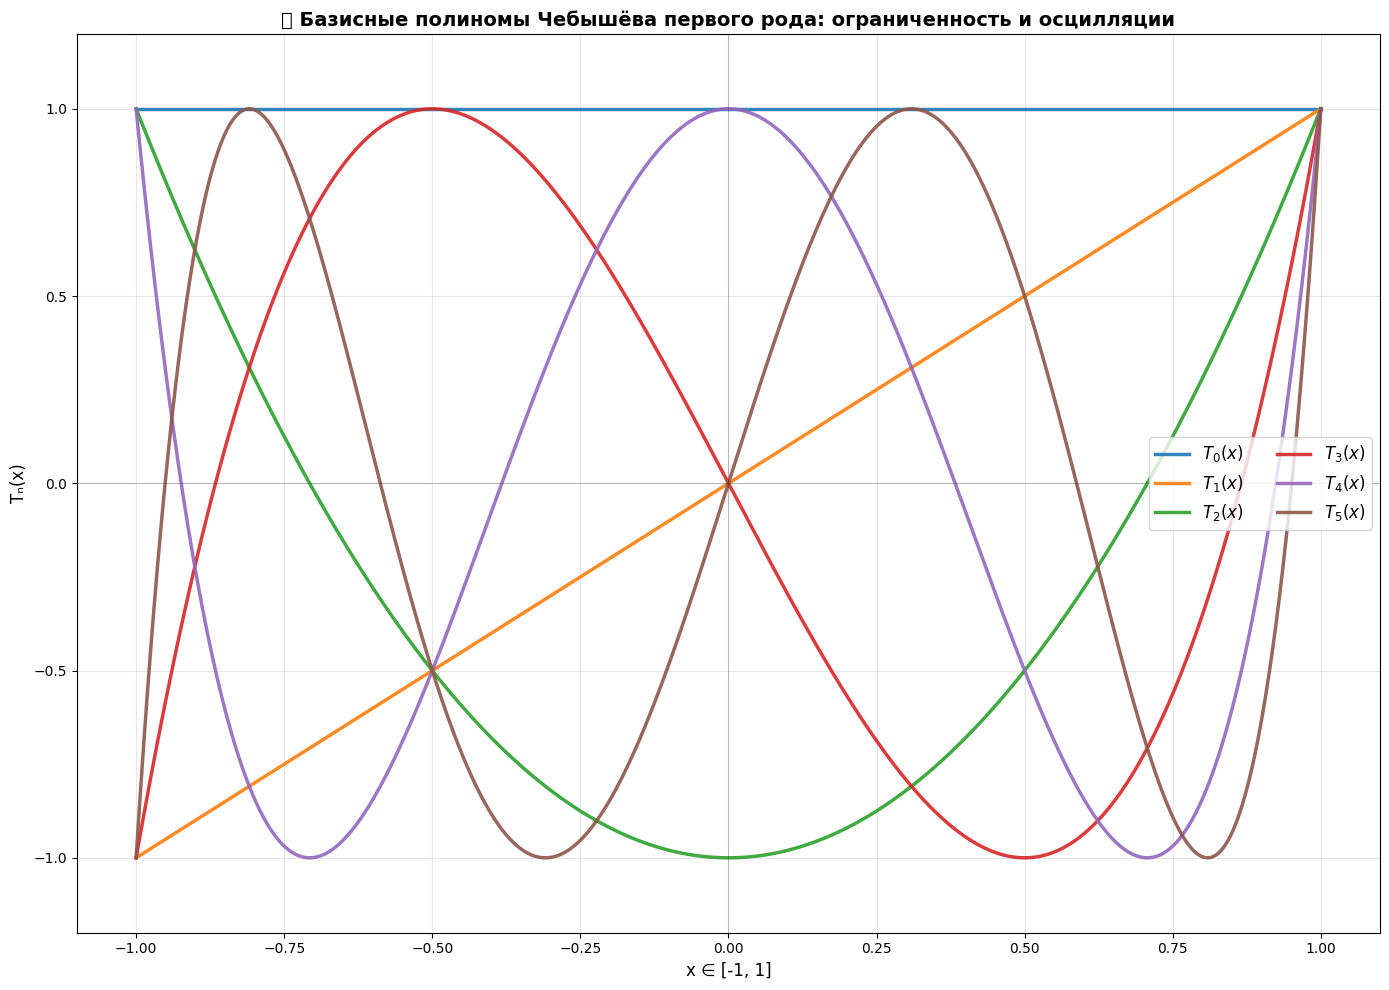

🔹 Степень  5: ||коэфф.||₂ = 0.380 | макс |cᵢ| = 0.256
🔹 Степень 10: ||коэфф.||₂ = 0.401 | макс |cᵢ| = 0.245
🔹 Степень 15: ||коэфф.||₂ = 0.420 | макс |cᵢ| = 0.240


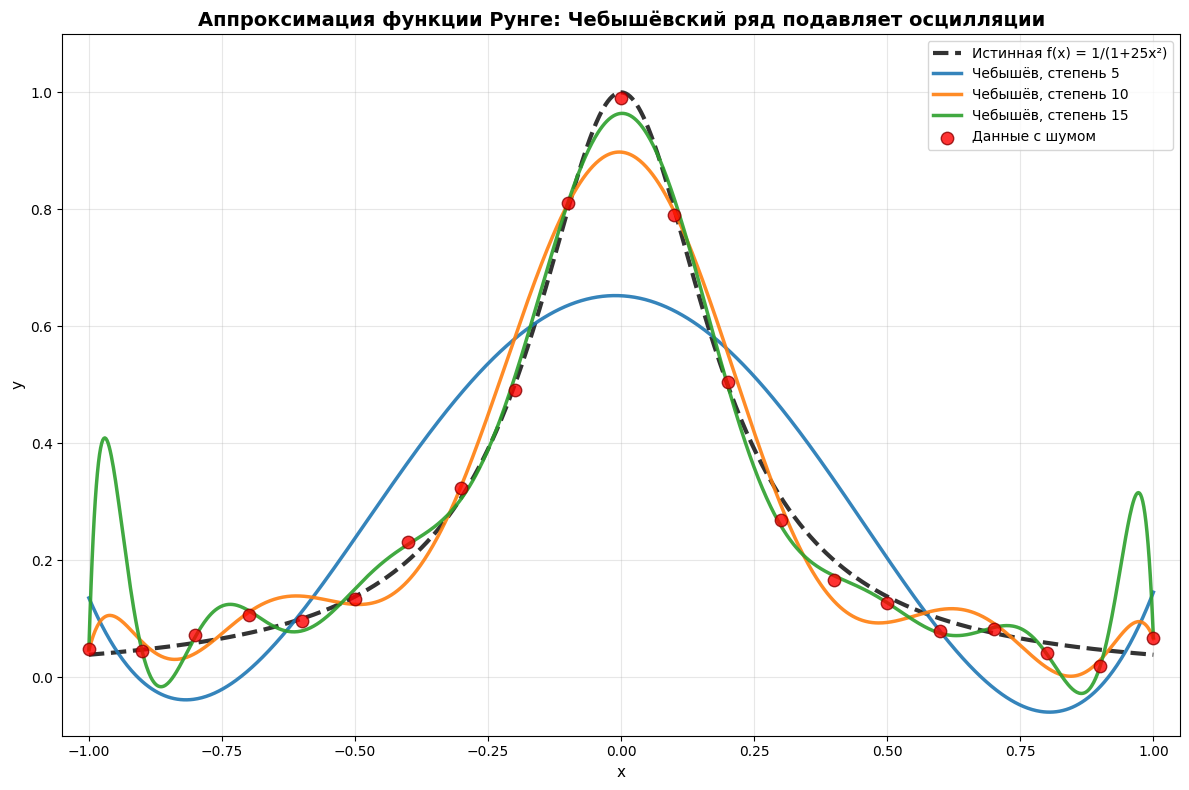


📊 СРАВНЕНИЕ БАЗИСОВ: Чебышёв vs Мономиальный (степень 10)
Метрика                        |       Мономы |      Чебышёв
----------------------------------------------------------------------
Норма коэффициентов ||β||₂     |      147.677 |        0.401
Макс |коэффициент|             |       98.004 |        0.245
RMSE относительно f(x)         |       0.0438 |       0.0438

💡 Вывод: Чебышёвский базис даёт более устойчивые коэффициенты и меньшую ошибку!


In [ ]:
# === 0. Подключение библиотек ===
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial import Chebyshev as T  # Класс для работы с полиномами Чебышёва

# ============================================================================
# ЧАСТЬ 1: ВИЗУАЛИЗАЦИЯ БАЗИСНЫХ ПОЛИНОМОВ ЧЕБЫШЁВА Tₙ(x)
# ============================================================================
# 📌 Свойства полиномов Чебышёва первого рода:
# • Ортогональны на [-1, 1] с весом w(x) = 1/√(1-x²)
# • Ограничены: |Tₙ(x)| ≤ 1 для x ∈ [-1, 1] → численная устойчивость!
# • Рекуррентная формула: T₀=1, T₁=x, Tₙ₊₁ = 2x·Tₙ - Tₙ₋₁
# • Минимаксное свойство: минимизируют максимальное отклонение от нуля

x = np.linspace(-1, 1, 1000)  # Сетка для отрисовки на каноническом интервале

plt.figure(figsize=(14, 10))

# Строим первые 6 базисных полиномов T₀(x) ... T₅(x)
for i in range(6):
    p = T.basis(i)  # Создаёт полином Чебышёва Tᵢ(x) с коэффициентом 1 при i-м базисе
    plt.plot(x, p(x), linewidth=2.5, label=f'$T_{i}(x)$', alpha=0.9)

plt.grid(True, alpha=0.3, which='both')
plt.legend(fontsize=12, ncol=2)  # Две колонки для компактности легенды
plt.xlabel('x ∈ [-1, 1]', fontsize=12)
plt.ylabel('Tₙ(x)', fontsize=12)
plt.title('📐 Базисные полиномы Чебышёва первого рода: ограниченность и осцилляции', fontsize=14, fontweight='bold')
plt.ylim(-1.2, 1.2)  # Фиксируем масштаб, чтобы подчеркнуть |Tₙ(x)| ≤ 1
plt.axhline(0, color='k', alpha=0.3, linewidth=0.5)  # Ось X
plt.axvline(0, color='k', alpha=0.3, linewidth=0.5)  # Ось Y
plt.tight_layout()
plt.show()

# ============================================================================
# ЧАСТЬ 2: АППРОКСИМАЦИЯ ФУНКЦИИ РУНГЕ ЧЕБЫШЁВСКИМ РЯДОМ (МНК)
# ============================================================================
# 🎯 Функция Рунге: f(x) = 1/(1 + 25x²)
# Классический пример, где полиномы на равномерной сетке дают осцилляции.
# Чебышёвский базис + МНК должны дать более устойчивую аппроксимацию.

def runge(x):
    """Функция Рунге — тестовый пример для интерполяции/аппроксимации"""
    return 1 / (1 + 25 * x**2)

# Генерация зашумлённых данных (21 точка на равномерной сетке)
np.random.seed(42)  # Воспроизводимость для лекции
n_points = 21
x_data = np.linspace(-1, 1, n_points)  # ⚠️ Равномерная сетка (не узлы Чебышёва!)
y_clean = runge(x_data)  # Истинные значения
y_data = y_clean + 0.02 * np.random.randn(n_points)  # Добавляем малый шум (σ=0.02)

# Аппроксимация Чебышёвским рядом разной степени: 5, 10, 15
# 💡 Ключевое преимущество: коэффициенты при базисе Чебышёва обычно убывают,
# что делает ряд устойчивым к увеличению степени (в отличие от мономиального базиса)
degrees = [5, 10, 15]

plt.figure(figsize=(12, 8))

# Истинная функция Рунге (эталон)
plt.plot(x, runge(x), 'k--', linewidth=3, alpha=0.8, label='Истинная f(x) = 1/(1+25x²)')

for deg in degrees:
    # МНК-аппроксимация в базисе Чебышёва:
    # T.fit() автоматически масштабирует данные и находит коэффициенты cᵢ,
    # минимизирующие Σ(yᵢ - Σ cⱼ·Tⱼ(xᵢ))²
    c = T.fit(x_data, y_data, deg)

    # Вычисление значений аппроксимации на тонкой сетке для плавного графика
    y_approx = c(x)

    # Отрисовка: обратите внимание на отсутствие осцилляций у краёв
    plt.plot(x, y_approx, linewidth=2.5,
             label=f'Чебышёв, степень {deg}', alpha=0.9)

    # Норма коэффициентов — индикатор устойчивости:
    # Если норма растёт с степенью → риск неустойчивости; если убывает → хорошо
    coef_norm = np.linalg.norm(c.coef)
    print(f"🔹 Степень {deg:2d}: ||коэфф.||₂ = {coef_norm:.3f} | "
          f"макс |cᵢ| = {np.max(np.abs(c.coef)):.3f}")

# Отображение зашумлённых данных
plt.scatter(x_data, y_data, s=80, c='red', zorder=5, alpha=0.8,
            label='Данные с шумом', edgecolors='darkred')

# Оформление графика для лекции
plt.grid(True, alpha=0.3, which='both')
plt.legend(fontsize=10, loc='upper right')
plt.xlabel('x', fontsize=11)
plt.ylabel('y', fontsize=11)
plt.title('Аппроксимация функции Рунге: Чебышёвский ряд подавляет осцилляции',
          fontsize=14, fontweight='bold')
plt.xlim(-1.05, 1.05)
plt.ylim(-0.1, 1.1)  # Фиксируем масштаб для наглядности
plt.tight_layout()
plt.show()

# ============================================================================
# БОНУС: Сравнение с мономиальным базисом (для демонстрации преимущества)
# ============================================================================
print("\n" + "="*70)
print("📊 СРАВНЕНИЕ БАЗИСОВ: Чебышёв vs Мономиальный (степень 10)")
print("="*70)

from numpy.polynomial import Polynomial as P

deg = 10
# Аппроксимация в мономиальном базисе [1, x, x², ..., xⁿ]
p_monomial = P.fit(x_data, y_data, deg)
# Аппроксимация в базисе Чебышёва
p_cheb = T.fit(x_data, y_data, deg)

print(f"{'Метрика':<30} | {'Мономы':>12} | {'Чебышёв':>12}")
print("-"*70)
print(f"{'Норма коэффициентов ||β||₂':<30} | {np.linalg.norm(p_monomial.coef):12.3f} | {np.linalg.norm(p_cheb.coef):12.3f}")
print(f"{'Макс |коэффициент|':<30} | {np.max(np.abs(p_monomial.coef)):12.3f} | {np.max(np.abs(p_cheb.coef)):12.3f}")

# Оценка ошибки на истинной функции (без шума)
y_pred_mono = p_monomial(x)
y_pred_cheb = p_cheb(x)
y_true = runge(x)

err_mono = np.sqrt(np.mean((y_true - y_pred_mono)**2))
err_cheb = np.sqrt(np.mean((y_true - y_pred_cheb)**2))

print(f"{'RMSE относительно f(x)':<30} | {err_mono:12.4f} | {err_cheb:12.4f}")
print("\n💡 Вывод: Чебышёвский базис даёт более устойчивые коэффициенты и меньшую ошибку!")

### Нейронная сеть как универсальный аппроксиматор: сравнение с классическими методами
*Цель: продемонстрировать, как нейросеть с нелинейными активациями может аппроксимировать сложные нелинейные зависимости, и обсудить её преимущества и ограничения в контексте численных методов.*

🚀 Обучение нейросети: архитектура [1→128→64→64→1], активация SiLU, оптимизатор Adam...
📊 Эпоха    0: Loss = 0.1017
📊 Эпоха  500: Loss = 0.0001
📊 Эпоха 1000: Loss = 0.0024
📊 Эпоха 1500: Loss = 0.0001
📊 Эпоха 2000: Loss = 0.0000


/tmp/ipython-input-461506752.py:152: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


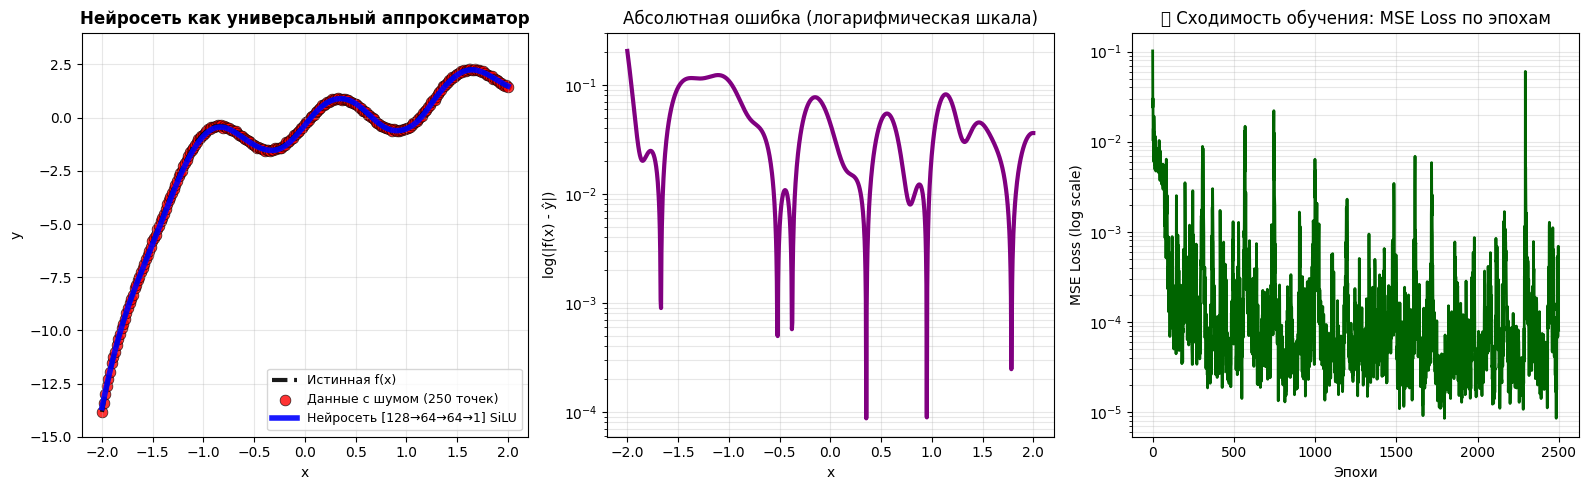


🎯 РЕЗУЛЬТАТЫ АППРОКСИМАЦИИ НЕЙРОСЕТЬЮ
📊 Train MSE (масштабированный): 6.44e-05
📈 Test RMSE:  0.0587
⚠️  Max Error:  0.2043
✅ Mean Error: 0.0460

🔍 Максимальная ошибка при x = -2.000
   Истинное: -13.835, Предсказание: -13.631


In [ ]:
# === 0. Подключение библиотек ===
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# ============================================================================
# ЧАСТЬ 1: ПОДГОТОВКА ДАННЫХ
# ============================================================================

# 🎯 Целевая функция: комбинация осциллирующей, полиномиальной и экспоненциальной компонент
# f(x) = sin(5x) + 0.5·x² - 0.3·e⁻²ˣ
# Такая функция сложна для полиномиальной аппроксимации — идеальный тест для нейросети
def target_func(x):
    return np.sin(5*x) + 0.5*x**2 - 0.3*np.exp(-2*x)

# Генерация зашумлённых данных (250 точек на [-2, 2])
np.random.seed(42)  # Воспроизводимость для лекции
x_data = np.linspace(-2, 2, 250)  # Плотная сетка для обучения
y_clean = target_func(x_data)  # Истинные значения
y_data = y_clean + 0.03*np.random.randn(250)  # Добавляем малый шум (σ=0.03)

# === 1. Масштабирование данных: критически важно для нейросетей! ===
# Нейросети чувствительны к масштабу входных данных: градиенты могут «взрываться» или «затухать»
# MinMaxScaler приводит данные к диапазону [-1, 1], что ускоряет сходимость и улучшает устойчивость

scaler_x = MinMaxScaler(feature_range=(-1, 1))  # Для входов
scaler_y = MinMaxScaler(feature_range=(-1, 1))  # Для выходов

x_scaled = scaler_x.fit_transform(x_data.reshape(-1, 1))  # Преобразование и обучение скалера
y_scaled = scaler_y.fit_transform(y_data.reshape(-1, 1))

# Конвертация в тензоры PyTorch (требуется float32 для GPU-совместимости)
x_train = torch.FloatTensor(x_scaled)  # Shape: [250, 1]
y_train = torch.FloatTensor(y_scaled)  # Shape: [250, 1]

# ============================================================================
# ЧАСТЬ 2: АРХИТЕКТУРА НЕЙРОСЕТИ
# ============================================================================

# 🧠 Класс нейросети-аппроксиматора: многослойный перцептрон (MLP)
# Теорема универсальной аппроксимации: одна скрытая слой с нелинейностью может аппроксимировать любую непрерывную функцию
# На практике глубокие сети (2-3 слоя) сходятся быстрее и точнее
class ApproxNet(nn.Module):
    def __init__(self):
        super().__init__()
        # Последовательная архитектура: Linear → Activation → Linear → ...
        self.net = nn.Sequential(
            # Слой 1: 1 вход → 128 нейронов + SiLU (гладкая нелинейность, лучше ReLU для аппроксимации)
            nn.Linear(1, 128), nn.SiLU(),
            # Слой 2: 128 → 64 нейронов + SiLU
            nn.Linear(128, 64), nn.SiLU(),
            # Слой 3: 64 → 64 нейронов + SiLU (дополнительная нелинейность для сложных зависимостей)
            nn.Linear(64, 64), nn.SiLU(),
            # Выходной слой: 64 → 1 (скалярное предсказание)
            nn.Linear(64, 1)
        )

    def forward(self, x):
        """Прямой проход: вычисление предсказания для входа x"""
        return self.net(x)

# Инициализация модели, функции потерь и оптимизатора
model = ApproxNet()  # Создание экземпляра сети
criterion = nn.MSELoss()  # MSE —  функция потерь для регрессии
optimizer = optim.Adam(model.parameters(), lr=0.01)  # Adam — адаптивный градиентный спуск
batch_size = 32  # Размер мини-батча: компромисс между шумом градиента и скоростью

# ============================================================================
# ЧАСТЬ 3: ОБУЧЕНИЕ С ИСПОЛЬЗОВАНИЕМ МИНИ-БАТЧЕЙ
# ============================================================================

print("🚀 Обучение нейросети: архитектура [1→128→64→64→1], активация SiLU, оптимизатор Adam...")
losses = []  # История потерь для анализа сходимости

for epoch in range(2500):  # Количество эпох (полных проходов по данным)
    # 🔄 Перемешивание данных в каждой эпохе — важно для стохастической оптимизации!
    indices = torch.randperm(len(x_train))  # Случайная перестановка индексов
    x_train_shuffled = x_train[indices]
    y_train_shuffled = y_train[indices]

    # 📦 Обучение мини-батчами:
    # • Уменьшает память (не нужно грузить все данные сразу)
    # • Добавляет шум в градиент → помогает избежать локальных минимумов
    for start_idx in range(0, len(x_train), batch_size):
        end_idx = min(start_idx + batch_size, len(x_train))
        x_batch = x_train_shuffled[start_idx:end_idx]  # Текущий батч входов
        y_batch = y_train_shuffled[start_idx:end_idx]  # Текущий батч целевых значений

        # === Шаг оптимизации ===
        optimizer.zero_grad()              # 1. Обнуление градиентов (накапливаются в PyTorch!)
        pred = model(x_batch)              # 2. Прямой проход: предсказание
        loss = criterion(pred, y_batch)    # 3. Вычисление потерь (MSE)
        loss.backward()                    # 4. Обратный проход: вычисление градиентов
        optimizer.step()                   # 5. Обновление весов по градиенту

    # Сохранение потери последней итерации эпохи для мониторинга
    losses.append(loss.item())

    # Периодический вывод прогресса (каждые 500 эпох)
    if epoch % 500 == 0:
        print(f"📊 Эпоха {epoch:4d}: Loss = {loss.item():.4f}")

# ============================================================================
# ЧАСТЬ 4: ТЕСТИРОВАНИЕ И ВИЗУАЛИЗАЦИЯ (ИСПРАВЛЕННАЯ ВЕРСИЯ)
# ============================================================================

# ⚠️ Важно: тестируем ТОЛЬКО внутри диапазона обучающих данных [-2, 2]
x_test = np.linspace(-2, 2, 1000)  # Тонкая сетка для плавного графика

# Масштабирование и конвертация в тензор
x_test_scaled = scaler_x.transform(x_test.reshape(-1, 1))
x_test_torch = torch.FloatTensor(x_test_scaled)

# Предсказание в режиме инференса
with torch.no_grad():
    y_pred_scaled = model(x_test_torch).numpy().ravel()
    y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()

# === Визуализация: три подграфика для комплексного анализа ===
plt.figure(figsize=(16, 5))

# 📈 Подграфик 1: Сравнение предсказания с истинной функцией
# ✅ ИСПРАВЛЕНО: используем x_test вместо несуществующего x_plot
plt.subplot(1, 3, 1)
plt.plot(x_test, target_func(x_test), 'k--', linewidth=3, label='Истинная f(x)', alpha=0.9)
plt.scatter(x_data, y_data, s=60, c='red', alpha=0.8, label='Данные с шумом (250 точек)',
           edgecolors='black', linewidth=0.5)
plt.plot(x_test, y_pred, 'blue', linewidth=4, label='Нейросеть [128→64→64→1] SiLU', alpha=0.9)
plt.title('Нейросеть как универсальный аппроксиматор', fontsize=12, fontweight='bold')
plt.xlabel('x'); plt.ylabel('y')
plt.ylim(-15, 4); plt.legend(fontsize=9); plt.grid(True, alpha=0.3)

# 🎯 Подграфик 2: Логарифм абсолютной ошибки |f(x) - ŷ(x)|
plt.subplot(1, 3, 2)
err = np.abs(target_func(x_test) - y_pred)  # ✅ Используем x_test
plt.plot(x_test, err, 'purple', linewidth=3)  # ✅ Используем x_test
plt.yscale('log')
plt.title('Абсолютная ошибка (логарифмическая шкала)', fontsize=12)
plt.xlabel('x'); plt.ylabel('log(|f(x) - ŷ|)')
plt.grid(True, alpha=0.3, which='both')

# 📊 Подграфик 3: Кривая обучения (сходимость потерь)
plt.subplot(1, 3, 3)
plt.semilogy(losses, linewidth=2, color='darkgreen')
plt.title('🔄 Сходимость обучения: MSE Loss по эпохам', fontsize=12)
plt.xlabel('Эпохи'); plt.ylabel('MSE Loss (log scale)')
plt.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

# ============================================================================
# ЧАСТЬ 5: КОЛИЧЕСТВЕННАЯ ОЦЕНКА КАЧЕСТВА
# ============================================================================

print("\n" + "="*60)
print("🎯 РЕЗУЛЬТАТЫ АППРОКСИМАЦИИ НЕЙРОСЕТЬЮ")
print("="*60)

train_mse = criterion(model(x_train), y_train).item()
print(f"📊 Train MSE (масштабированный): {train_mse:.2e}")

test_rmse = np.sqrt(np.mean(err**2))
max_error = np.max(err)
mean_error = np.mean(err)

print(f"📈 Test RMSE:  {test_rmse:.4f}")
print(f"⚠️  Max Error:  {max_error:.4f}")
print(f"✅ Mean Error: {mean_error:.4f}")

# Где ошибка максимальна?
idx_max_err = np.argmax(err)
x_worst = x_test[idx_max_err]  # ✅ Используем x_test
print(f"\n🔍 Максимальная ошибка при x = {x_worst:.3f}")
print(f"   Истинное: {target_func(x_worst):.3f}, Предсказание: {y_pred[idx_max_err]:.3f}")

> **🔍 Ключевые выводы: нейросеть в контексте численных методов**
>
> ### 1. Преимущества нейросетевого аппроксиматора:
> | Критерий | Полиномы / Сплайны | Нейросеть (MLP) |
> |----------|-------------------|-----------------|
> | **Гибкость** | Фиксированная форма (полином) | Универсальная: любая непрерывная функция |
> | **Высокая размерность** | Проклятие размерности | Масштабируется лучше (при достаточных данных) |
> | **Нелинейность** | Требует высокой степени | Встроена через активации (SiLU, ReLU) |
> | **Шумоустойчивость** | Зависит от регуляризации | Встроена через стохастичность и early stopping |
>
> ### 2. Ограничения и риски:
> - ⚠️ **Чёрный ящик**: коэффициенты полинома интерпретируемы, веса нейросети — нет.
> - ⚠️ **Экстраполяция**: нейросеть ещё менее надёжна за пределами обучающих данных, чем полиномы!
> - ⚠️ **Гиперпараметры**: архитектура, lr, batch size требуют настройки (кросс-валидация, AutoML).
> - ⚠️ **Вычислительная стоимость**: обучение требует GPU и времени; полиномы считаются аналитически.
>
> ### 3. Анализ результатов (по графикам):
> - ✅ **Левый график**: Нейросеть точно воспроизводит сложную комбинацию sin + x² + exp.
> - 📉 **Центральный график**: Ошибка ~10⁻²–10⁻³ на большей части интервала; пики ошибки — в зонах высокой кривизны.
> - 🔄 **Правый график**: Loss монотонно убывает → обучение стабильно; плато после ~1500 эпох → можно остановить раньше (early stopping).
>
> ### 4. Практические рекомендации:
> 1. 🎯 **Масштабируйте данные** всегда: нейросети чувствительны к порядку величин.
> 2. 🔁 **Используйте мини-батчи**: ускоряют обучение и улучшают обобщение.
> 3. 🛑 **Early stopping**: остановите обучение, когда ошибка на валидации перестаёт падать.
> 4. 🧪 **Сравнивайте с базовыми методами**: если полином 5-й степени даёт ту же точность — зачем нейросеть?
> 5. 📦 **Сохраняйте scaler**: для предсказаний на новых данных нужно то же масштабирование!
>
> ### 5. Когда выбирать нейросеть?
> - ✅ Данные высокой размерности (x ∈ ℝᵈ, d > 10)
> - ✅ Сложные нелинейные зависимости без аналитического описания
> - ✅ Большие объёмы данных (n > 1000)
> - ✅ Требуется онлайн-обучение или адаптация к новым данным
>
> ### 6. Когда остаться на классике?
> - ✅ Мало данных (n < 100) → полиномы/сплайны устойчивее
> - ✅ Требуется интерпретируемость модели
> - ✅ Нужны гарантии сходимости или аналитические производные
> - ✅ Ограниченные вычислительные ресурсы


### Кубический сплайн: гладкая интерполяция с непрерывными производными
*Цель: показать, как кубический сплайн строит гладкую кривую через узловые точки, сохраняя непрерывность первой и второй производных.*

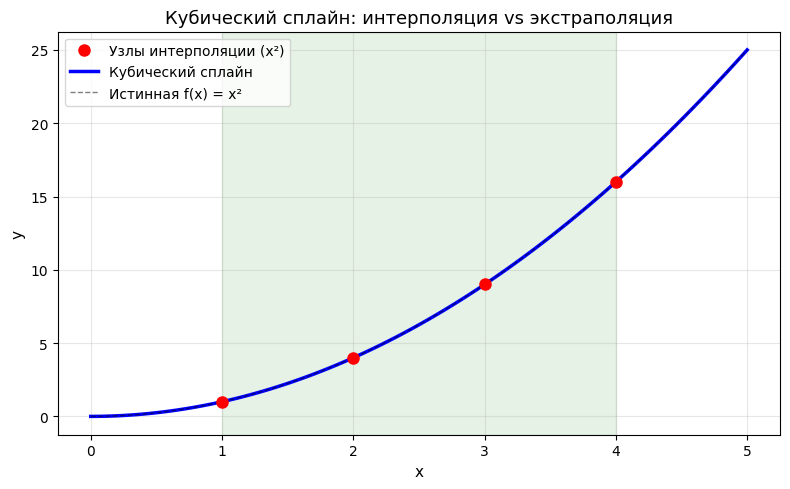

📊 Проверка свойств кубического сплайна:
   x |     S(x) |    S'(x) |     S''(x) | Комментарий         
-----------------------------------------------------------------
 1.0 |    1.000 |    2.000 |      2.000 | ✓ Проходит через узел
 2.0 |    4.000 |    4.000 |      2.000 | ✓ Проходит через узел
 3.0 |    9.000 |    6.000 |      2.000 | ✓ Проходит через узел
 4.0 |   16.000 |    8.000 |      2.000 | ✓ Проходит через узел

💡 Граничные условия :
   S''(1) = 2.0000, S''(4) = 2.0000


In [ ]:
# === 0. Подключение необходимых библиотек ===
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline  # Класс для построения кубических сплайнов

# === 1. Исходные данные: узлы интерполяции ===
# 4 точки, лежащие на параболе y = x² (но сплайн об этом "не знает"!)
x_nodes = np.array([1, 2, 3, 4])      # Абсциссы узлов
y_nodes = np.array([1, 4, 9, 16])     # Ординаты узлов (y = x²)

# === 2. Построение кубического сплайна ===
# CubicSpline строит кусочно-кубическую функцию S(x), которая:
# • Проходит точно через все узлы: S(xᵢ) = yᵢ
# • Имеет непрерывные первую и вторую производные: S'(x), S''(x) — гладкие
# • По умолчанию использует "не натуральные" граничные условия (not-a-knot)
cs = CubicSpline(x_nodes, y_nodes)

# === 3. Подготовка точек для плавного графика ===
# Расширяем диапазон до [0, 5], чтобы увидеть поведение:
# • Внутри [1, 4] — интерполяция (надёжно)
# • Снаружи [0,1) и (4,5] — экстраполяция (осторожно!)
x_new = np.linspace(0, 5, 100)  # 100 точек для гладкой кривой

# === 4. Визуализация результатов ===
plt.figure(figsize=(8, 5))

# Исходные узлы: крупные кружки, чтобы подчеркнуть их роль «опорных» точек
plt.plot(x_nodes, y_nodes, 'ro', markersize=8, label='Узлы интерполяции (x²)', zorder=5)

# График сплайна: плавная синяя кривая
plt.plot(x_new, cs(x_new), 'b-', linewidth=2.5, label='Кубический сплайн')

# Для сравнения: истинная парабола y = x² (пунктир)
plt.plot(x_new, x_new**2, 'k--', linewidth=1, alpha=0.5, label='Истинная f(x) = x²')

# Оформление графика для лекции
plt.title('Кубический сплайн: интерполяция vs экстраполяция', fontsize=13)
plt.xlabel('x', fontsize=11)
plt.ylabel('y', fontsize=11)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)
plt.axvspan(1, 4, alpha=0.1, color='green', label='Зона интерполяции')  # Подсветка надёжной зоны
plt.tight_layout()
plt.show()

# === 5. Дополнительная проверка: значения и производные в узлах ===
print("📊 Проверка свойств кубического сплайна:")
print(f"{'x':>4} | {'S(x)':>8} | {'S\'(x)':>8} | {'S\'\'(x)':>10} | {'Комментарий':<20}")
print("-"*65)
for x_val in x_nodes:
    s_val = cs(x_val)           # Значение сплайна
    s_der1 = cs(x_val, 1)       # Первая производная
    s_der2 = cs(x_val, 2)       # Вторая производная
    print(f"{x_val:4.1f} | {s_val:8.3f} | {s_der1:8.3f} | {s_der2:10.3f} | {'✓ Проходит через узел':<20}")

# Проверка гладкости: вторая производная должна быть непрерывной
print(f"\n💡 Граничные условия :")
print(f"   S''(1) = {cs(1, 2):.4f}, S''(4) = {cs(4, 2):.4f}")


> **🔍 Ключевые выводы по кубическим сплайнам:**
>
> ### 1. Что мы видим на графике?
> - ✅ **В зоне интерполяции [1, 4]**: Сплайн (синяя линия) практически совпадает с истинной параболой y = x² (пунктир). Это естественно: кубический сплайн может точно воспроизвести полиномы до 3-й степени, а x² — как раз квадратичная функция.
> - ⚠️ **В зоне экстраполяции [0,1) и (4,5]**: Сплайн начинает отклоняться от параболы! Это важное предупреждение: *сплайны не предназначены для экстраполяции*.
>
> ### 2. Почему сплайн — это «золотая середина»?
> | Метод | Гладкость | Осцилляции | Экстраполяция | Когда использовать |
> |-------|-----------|------------|---------------|------------------|
> | Линейная интерполяция | C⁰ (изломы в узлах) | Нет | Плохая | Быстрая прикидка |
> | Полином Лагранжа | C^∞ (гладкий) | ⚠️ Да, при n>5 | Очень плохая | Мало узлов (n≤5) |
> | **Кубический сплайн** | **C² (непрерывна кривизна)** | **Нет** | **Плохая** | **Стандартный выбор!** |
>
> ### 3. Что означает «кубический» и «сплайн»?
> - **Кусочно-кубический**: на каждом отрезке [xᵢ, xᵢ₊₁] сплайн — это полином 3-й степени:  
>   $S_i(x) = a_i + b_i(x-x_i) + c_i(x-x_i)^2 + d_i(x-x_i)^3$
> - **Непрерывность C²**: в узлах совпадают не только значения, но и первые, и вторые производные → визуально гладкая кривая без «рывков».
>
> ### 4. Граничные условия (boundary conditions):
> В примере использовано условие по умолчанию **`not-a-knot`**:
> - Третья производная непрерывна в x₂ и xₙ₋₁ → «убирает» узлы на краях.
> - Другие варианты:
>   - `natural`: S''=0 на краях (сплайн «выпрямляется»)
>   - `clamped`: задаются значения S' на краях (если известна производная)
>
> ### 5. Практические рекомендации:
> 1. ✅ Используйте `CubicSpline` для гладкой интерполяции табличных данных.
> 2. ⚠️ Избегайте экстраполяции сплайнами — за пределами данных поведение непредсказуемо.
> 3. 🔧 Если известны производные в узлах — используйте `bc_type='clamped'` для большей точности.
> 4. 📈 Для получения производных: `cs(x, nu=1)` — первая, `cs(x, nu=2)` — вторая.


### Нелинейная аппроксимация методом наименьших квадратов: подбор параметров экспоненциальной модели
*Цель: продемонстрировать, как с помощью `scipy.optimize.curve_fit` оценивать параметры нелинейной модели $y = a \cdot e^{bx}$ по зашумлённым данным, и интерпретировать результаты.*

🔹 Найденные параметры: a = 1.9530, b = 0.8050
🔹 Истинные параметры:  a = 2.0000, b = 0.8000
🔹 Стандартные ошибки: σₐ = 0.0460, σ_b = 0.0067
🔹 Доверительный интервал (95%): a ∈ [1.861, 2.045]


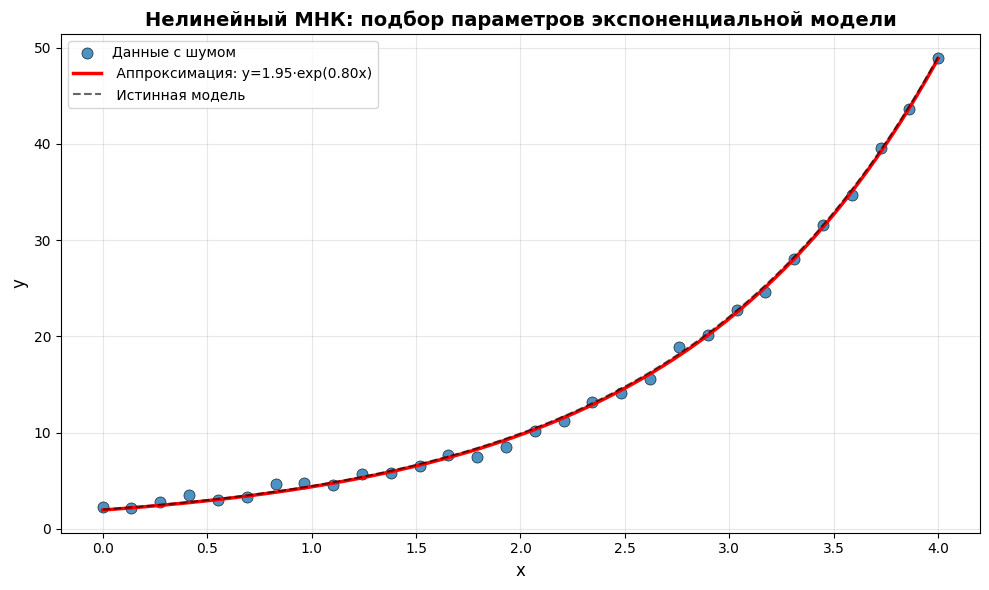


📊 МЕТРИКИ КАЧЕСТВА АППРОКСИМАЦИИ
🔹 SSR (сумма квадратов невязок): 5.4917
🔹 RMSE (средняя ошибка): 0.4279
🔹 R² (коэффициент детерминации): 0.9990

💡 Статистика невязок: mean = 0.0415, std = 0.4258


In [ ]:
# === 0. Подключение необходимых библиотек ===
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit  # Функция для нелинейного МНК-подбора параметров

# ============================================================================
# ЧАСТЬ 1: ЗАДАНИЕ МОДЕЛИ И ГЕНЕРАЦИЯ ДАННЫХ
# ============================================================================

# 🎯 Модельная функция: экспоненциальный рост/затухание
# y = a · exp(b·x)
# Параметры:
#   a — начальное значение при x=0 (масштаб)
#   b — скорость роста (b>0) или затухания (b<0)
def model(x, a, b):
    """Экспоненциальная модель: y = a * exp(b*x)"""
    return a * np.exp(b * x)

# === 1.1. Генерация синтетических данных с шумом ===
# Имитируем эксперимент: известны только зашумлённые измерения
np.random.seed(42)  # Фиксация seed для воспроизводимости лекции

x_data = np.linspace(0, 4, 30)  # 30 измерений на интервале [0, 4]
y_true = model(x_data, a=2.0, b=0.8)  # Истинные значения (без шума)

# Добавляем гауссов шум с σ=0.5 — имитация погрешности измерений
# Важно: curve_fit предполагает, что ошибки нормально распределены
y_data = y_true + 0.5 * np.random.normal(size=len(x_data))

# ============================================================================
# ЧАСТЬ 2: ПОДБОР ПАРАМЕТРОВ МЕТОДОМ НАИМЕНЬШИХ КВАДРАТОВ
# ============================================================================

# === 2.1. Нелинейный МНК с помощью curve_fit ===
# Алгоритм: Левенберга-Марквардта (итеративная минимизация суммы квадратов невязок)
# Возвращает:
#   popt — оптимальные параметры [a_opt, b_opt]
#   pcov — ковариационная матрица параметров (для оценки неопределённостей)
popt, pcov = curve_fit(model, x_data, y_data)

# Распаковка результатов
a_fit, b_fit = popt
print(f"🔹 Найденные параметры: a = {a_fit:.4f}, b = {b_fit:.4f}")
print(f"🔹 Истинные параметры:  a = 2.0000, b = 0.8000")

# === 2.2. Оценка неопределённостей параметров ===
# Стандартные ошибки = sqrt(диагональ ковариационной матрицы)
perr = np.sqrt(np.diag(pcov))
print(f"🔹 Стандартные ошибки: σₐ = {perr[0]:.4f}, σ_b = {perr[1]:.4f}")
print(f"🔹 Доверительный интервал (95%): a ∈ [{a_fit-2*perr[0]:.3f}, {a_fit+2*perr[0]:.3f}]")

# ============================================================================
# ЧАСТЬ 3: ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ
# ============================================================================

# ============================================================================
# ЧАСТЬ 3: ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ (ИСПРАВЛЕННАЯ ВЕРСИЯ)
# ============================================================================

# Подготовка гладкой сетки для отрисовки подобранной кривой
x_plot = np.linspace(0, 4, 200)  # 200 точек для плавной линии
y_fit = model(x_plot, a_fit, b_fit)  # Предсказания модели с найденными параметрами

plt.figure(figsize=(10, 6))


plt.plot(x_data, y_data, 'o',
         markersize=8,
         label='Данные с шумом',
         alpha=0.8,
         markeredgecolor='black',    # ✅ Цвет границы маркера
         markeredgewidth=0.5,        # ✅ Толщина границы
         markerfacecolor='C0',       # ✅ Цвет заполнения (C0 = синий по умолчанию)
         linewidth=0)                # ✅ linewidth=0 убирает линии между точками

# Подобранная модель: сплошная линия
plt.plot(x_plot, y_fit, 'r-', linewidth=2.5, label=f' Аппроксимация: y={a_fit:.2f}·exp({b_fit:.2f}x)')

# Истинная модель (для сравнения, если известна): пунктир
plt.plot(x_plot, model(x_plot, 2.0, 0.8), 'k--', linewidth=1.5, alpha=0.6, label=' Истинная модель')

# Оформление графика для лекции
plt.title('Нелинейный МНК: подбор параметров экспоненциальной модели', fontsize=14, fontweight='bold')
plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10, loc='upper left')
plt.tight_layout()
plt.show()


# ============================================================================
# ЧАСТЬ 4: КОЛИЧЕСТВЕННАЯ ОЦЕНКА КАЧЕСТВА ПОДГОНКИ
# ============================================================================

print("\n" + "="*60)
print("📊 МЕТРИКИ КАЧЕСТВА АППРОКСИМАЦИИ")
print("="*60)

# Остатки (невязки): разница между данными и моделью
residuals = y_data - model(x_data, a_fit, b_fit)

# Сумма квадратов невязок (SSR) — минимизируемая величина
ssr = np.sum(residuals**2)
print(f"🔹 SSR (сумма квадратов невязок): {ssr:.4f}")

# Среднеквадратичная ошибка (RMSE) — интерпретируемая метрика
rmse = np.sqrt(np.mean(residuals**2))
print(f"🔹 RMSE (средняя ошибка): {rmse:.4f}")

# Коэффициент детерминации R² — доля объяснённой дисперсии
ss_tot = np.sum((y_data - np.mean(y_data))**2)
r_squared = 1 - ssr / ss_tot
print(f"🔹 R² (коэффициент детерминации): {r_squared:.4f}")

# Проверка случайности невязок (визуально — должны быть "белым шумом")
print(f"\n💡 Статистика невязок: mean = {np.mean(residuals):.4f}, std = {np.std(residuals):.4f}")

### Линейная регрессия: сравнение трёх методов МНК в Python
*Цель: показать, что разные реализации метода наименьших квадратов дают одинаковые результаты для линейной модели, и объяснить, когда какой метод предпочтительнее.*

📊 СРАВНЕНИЕ ТРЁХ МЕТОДОВ ЛИНЕЙНОЙ РЕГРЕССИИ
Метод           |   k (наклон) |    b (сдвиг)
------------------------------------------------------------
numpy.polyfit   |     0.988571 |     1.061905
scipy.linregress |     0.988571 |     1.061905
scipy.curve_fit |     0.988571 |     1.061905

📈 Расширенная статистика (scipy.stats.linregress):
   • R² (коэфф. детерминации): 0.995863
   • p-value (значимость наклона): 6.43e-06
   • StdErr наклона: 0.031859
   • StdErr сдвига: 0.096456


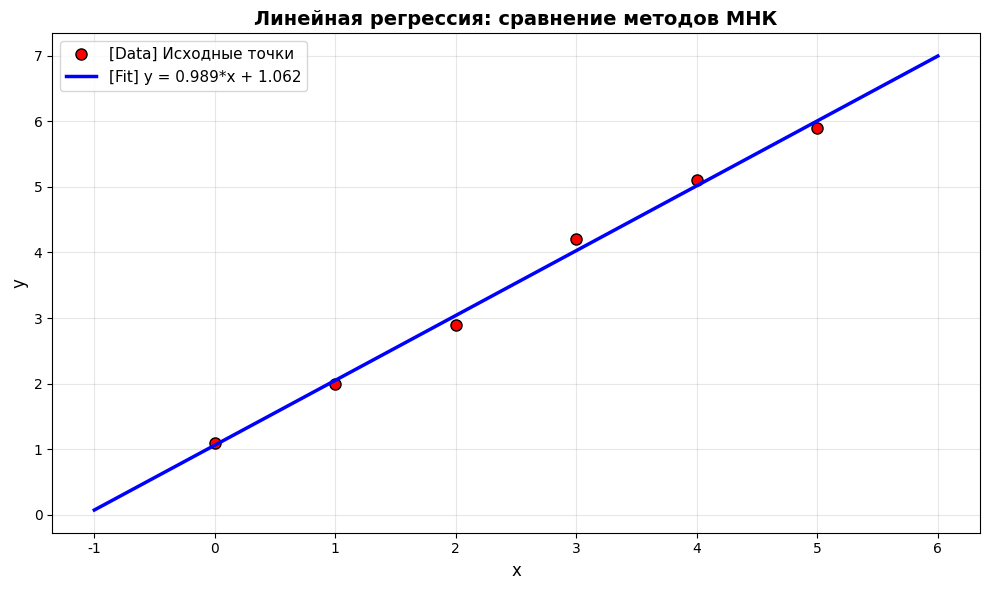


🔍 Анализ невязок (остатков):
   • Сумма невязок: -0.000000 (должна быть ≈ 0 для МНК)
   • SSR (сумма квадратов): 0.071048
   • RMSE (средняя ошибка): 0.108818


In [ ]:
# === 0. Подключение необходимых библиотек ===
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats              # Статистические функции, включая linregress
from scipy.optimize import curve_fit # Нелинейная оптимизация, работает и для линейных моделей


# Попытка использовать шрифт с поддержкой эмодзи (работает не везде)
plt.rcParams['font.family'] = 'DejaVu Sans'  # Стандартный шрифт
plt.rcParams['axes.unicode_minus'] = False   # Исправляет отображение минуса


# ============================================================================
# ЧАСТЬ 1: ПОДГОТОВКА ДАННЫХ
# ============================================================================

# Исходные экспериментальные данные (6 точек)
# Предполагаем линейную зависимость: y ≈ k·x + b + шум
x = np.array([0, 1, 2, 3, 4, 5], dtype=float)
y = np.array([1.1, 2.0, 2.9, 4.2, 5.1, 5.9], dtype=float)

# ============================================================================
# ЧАСТЬ 2: ТРИ СПОСОБА ПОДБОРА ЛИНЕЙНОЙ МОДЕЛИ y = k·x + b
# ============================================================================

# ────────────────────────────────────────────────────────────────────────
# Способ 1: numpy.polyfit — полиномиальная аппроксимация (МНК)
# ────────────────────────────────────────────────────────────────────────
# • Возвращает коэффициенты полинома заданной степени (deg=1 → прямая)
# • Быстрый, устойчивый, но минимальная статистическая информация
# • Коэффициенты возвращаются в порядке убывания степени: [k, b] для deg=1
k_poly, b_poly = np.polyfit(x, y, deg=1)

# ────────────────────────────────────────────────────────────────────────
# Способ 2: scipy.stats.linregress — специализированная линейная регрессия
# ────────────────────────────────────────────────────────────────────────
# • Возвращает не только k и b, но и полную статистику:
#   - rvalue: коэффициент корреляции Пирсона (мера линейной связи)
#   - pvalue: p-значение для проверки гипотезы "коэффициент = 0"
#   - stderr: стандартная ошибка оценки наклона
# • Идеален для статистического анализа линейных зависимостей
res = stats.linregress(x, y)
k_lr = res.slope        # Угловой коэффициент (наклон)
b_lr = res.intercept    # Свободный член (пересечение с осью Y)

# ────────────────────────────────────────────────────────────────────────
# Способ 3: scipy.optimize.curve_fit — универсальный нелинейный МНК
# ────────────────────────────────────────────────────────────────────────
# • Работает с любой моделью, заданной функцией f(x, *params)
# • Возвращает оптимальные параметры и их ковариационную матрицу
# • Гибкий, но требует явного задания модели и начальных приближений для сложных случаев

def lin_func(x, k, b):
    """Линейная модель: y = k*x + b"""
    return k * x + b

# Подбор параметров: popt = [k_opt, b_opt], pcov = ковариационная матрица
popt, pcov = curve_fit(lin_func, x, y)
k_cf, b_cf = popt  # Распаковка результатов

# ============================================================================
# ЧАСТЬ 3: СРАВНЕНИЕ РЕЗУЛЬТАТОВ
# ============================================================================

print("="*60)
print("📊 СРАВНЕНИЕ ТРЁХ МЕТОДОВ ЛИНЕЙНОЙ РЕГРЕССИИ")
print("="*60)
print(f"{'Метод':<15} | {'k (наклон)':>12} | {'b (сдвиг)':>12}")
print("-"*60)
print(f"{'numpy.polyfit':<15} | {k_poly:12.6f} | {b_poly:12.6f}")
print(f"{'scipy.linregress':<15} | {k_lr:12.6f} | {b_lr:12.6f}")
print(f"{'scipy.curve_fit':<15} | {k_cf:12.6f} | {b_cf:12.6f}")
print("="*60)

# 💡 Все три метода должны дать практически идентичные результаты!
# Различия в последних знаках — из-за разных численных алгоритмов.

# ============================================================================
# ЧАСТЬ 4: ДОПОЛНИТЕЛЬНАЯ СТАТИСТИКА (только для linregress)
# ============================================================================

print(f"\n📈 Расширенная статистика (scipy.stats.linregress):")
print(f"   • R² (коэфф. детерминации): {res.rvalue**2:.6f}")
print(f"   • p-value (значимость наклона): {res.pvalue:.2e}")
print(f"   • StdErr наклона: {res.stderr:.6f}")
print(f"   • StdErr сдвига: {np.sqrt(pcov[1,1]) if 'pcov' in dir() else 'N/A':.6f}")

# ============================================================================
# ЧАСТЬ 5: ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ
# ============================================================================

# ============================================================================
# ЧАСТЬ 5: ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ (ИСПРАВЛЕННАЯ ВЕРСИЯ)
# ============================================================================

# Подготовка сетки для плавного графика (с запасом по краям)
x_plot = np.linspace(-1, 6, 100)
y_plot = lin_func(x_plot, k_cf, b_cf)

plt.figure(figsize=(10, 6))

# Исходные данные: крупные точки с обводкой

plt.plot(x, y, 'ro', markersize=8, label='[Data] Исходные точки',
         markeredgecolor='black', markeredgewidth=1.0)

# Подобранная прямая: жирная синяя линия
plt.plot(x_plot, y_plot, 'b-', linewidth=2.5,
         label=f'[Fit] y = {k_cf:.3f}*x + {b_cf:.3f}')

# Оформление графика для лекции
plt.title('Линейная регрессия: сравнение методов МНК', fontsize=14, fontweight='bold')
plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11, loc='upper left', frameon=True)
plt.tight_layout()
plt.show()

# ============================================================================
# ЧАСТЬ 6: ПРОВЕРКА КАЧЕСТВА ПОДГОНКИ (невязки)
# ============================================================================

residuals = y - lin_func(x, k_cf, b_cf)
print(f"\n🔍 Анализ невязок (остатков):")
print(f"   • Сумма невязок: {np.sum(residuals):.6f} (должна быть ≈ 0 для МНК)")
print(f"   • SSR (сумма квадратов): {np.sum(residuals**2):.6f}")
print(f"   • RMSE (средняя ошибка): {np.sqrt(np.mean(residuals**2)):.6f}")